(chap8)=

# 第八章：近似贝叶斯计算

本章讨论近似贝叶斯计算（Approximate Bayesian Computation，ABC）。ABC 中的
“近似”是指没有显式似然，而不是指用马尔可夫链蒙特卡洛或变分推断等数值
方法近似后验。ABC 的另一个常见且更直接的名称是“无似然方法”
（likelihood-free methods）；有些作者区分这两个术语，也有作者交替使用它们。

当我们没有似然的显式表达式，却拥有一个能生成合成数据的参数化*模拟器*
（simulator）时，ABC 方法可能很有用。模拟器含有一个或多个未知参数；我们的
目标是找出哪些参数能生成与观测数据“足够接近”的合成数据，并由此计算这些
参数的后验分布。

ABC 在生物科学中日益常见，尤其用于系统生物学、流行病学、生态学和群体遗传学
{cite:p}`Sunnaker2013`。它也用于许多其他领域，因为它为大量实际问题提供了灵活
的求解方式。可用的 Python ABC 软件包同样反映了这种多样性
{cite:p}`Dutta2017, Lintusaari2018, Klinger2018`。不过，额外的一层近似也带来
自己的困难：最主要的是在没有似然时定义何谓“足够接近”，以及如何真正计算近似
后验。

本章从一般视角讨论这些挑战。若读者希望把 ABC 应用于自己的问题，我们强烈建议
将本章与所属领域的实例和专业知识结合起来阅读。

> **中文版现代化说明。** 正文以 `markdown/chp_08.md` 为完整文字权威，代码以
> `notebooks_updated/chp_08.ipynb` 为起点。原版中的 PyMC3、`MultiTrace`、旧式
> 后验预测 API 和全局 NumPy 随机状态已迁移到当前 PyMC、ArviZ
> `InferenceData`、当前 `sample_posterior_predictive` API 与显式随机数生成器。
> 修复了 MA(1)/MA(2) 滞后索引、g-and-k 抽样及对数边际似然比等问题；这些改动
> 均不改变本章的统计学主线。构建源保留原始锚点、引用、图表、脚注和练习。


In [1]:
from functools import partial
from pathlib import Path
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

from scripts.rf_selector import select_model

EXECUTION_PROFILE = os.environ.get("BMCP_EXECUTION_PROFILE", "release").lower()
if EXECUTION_PROFILE not in {"smoke", "release"}:
    raise ValueError("BMCP_EXECUTION_PROFILE 必须是 smoke 或 release")

if EXECUTION_PROFILE == "smoke":
    SMC_DRAWS = 100
    MA_SMC_DRAWS = 100
    NUTS_DRAWS = 100
    NUTS_TUNE = 100
    CHAINS = 2
    PPC_SAMPLES = 50
    RF_REFERENCE_SAMPLES = 80
    RF_TREES = 40
else:
    SMC_DRAWS = 2000
    MA_SMC_DRAWS = 3000
    NUTS_DRAWS = 1000
    NUTS_TUNE = 1000
    CHAINS = 4
    PPC_SAMPLES = 100
    RF_REFERENCE_SAMPLES = 5000
    RF_TREES = 100

RANDOM_SEED = 1346
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-grayscale")
plt.rcParams["figure.dpi"] = 150

FIG_DIR = Path("img/chp08")
DATA_DIR = Path("data")
FIG_DIR.mkdir(parents=True, exist_ok=True)


(life-beyond-likelihood)=

## 似然之外的世界

根据贝叶斯定理（公式 [eq:posterior_dist](eq:posterior_dist)），计算后验需要两个
基本要素：先验和似然。然而，在某些问题中，似然无法写成闭式，或者计算成本高得
无法承受。这似乎会让我们的贝叶斯热情走进死胡同，但只要能以某种方式生成合成
数据，事情就未必如此。合成数据生成器通常称为*模拟器*。从 ABC 的角度看，模拟器
是一个黑箱：一端输入参数值，另一端输出模拟数据。新增的不确定性在于，哪些输入
足以生成与观测数据相似的合成数据。

所有 ABC 方法共有的基本思想，是用一个 $\delta$ 函数替代似然。该函数计算观测
数据 $Y$ 与参数化模拟器 $Sim$ 生成的合成数据 $\hat Y$ 之间的距离，或更一般的
差异度：

```{math}
:label: eq:simulator
\hat Y \sim Sim(\theta)
```

```{math}
:label: eq:approx_likelihood
p(\theta \mid Y)
    \underset{\sim}{\propto}
    \delta(Y, \hat Y \mid \epsilon)\;p(\boldsymbol{\theta})
```

我们希望借助 $\delta$ 得到对*真实*似然“在实践中足够好”的近似：

```{math}
:label: eq:converge_true_likelihood
\lim_{\epsilon \to 0}\delta(Y, \hat Y \mid \epsilon)
= p(Y \mid \boldsymbol{\theta})
```

之所以引入容忍参数 $\epsilon$，是因为在多数问题中，合成数据集 $\hat Y$ 与观测
数据 $Y$ 完全相等的概率几乎为零[^1]。$\epsilon$ 越大，我们判定两者“足够接近”
时越宽容。对同一个问题而言，较大的 $\epsilon$ 通常意味着更粗糙的后验近似；后文
会看到实例。

随着样本量（或数据维数）增加，越来越难让距离函数 $\delta$ 取得足够小的值[^2]。
直接增大 $\epsilon$ 虽然简单，却会增大近似误差。更好的做法可能是使用一个或多个
摘要统计量 $S$，比较数据摘要而不是完整的模拟数据集与真实数据集：

```{math}
:label: eq:summary_statistics
\delta\left(S(Y), S(\hat Y) \mid \epsilon\right)
```

必须意识到，使用摘要统计量会给 ABC 近似再引入一个误差来源；只有摘要统计量关于
模型参数 $\theta$ 充分时才不会如此。充分统计量并非总能找到，但非充分摘要在实践
中仍然非常有用，也经常被采用。

本章会考察若干距离和摘要统计量，并把重点放在已有实践依据的方法上。ABC 面对的
模拟数据类型和应用领域极其多样，很难给出放之四海而皆准的规则；同时相关文献发展
很快。因此，我们着重建立必要的知识、技能和工具，使读者能随 ABC 方法演进而迁移
到新问题。

::: {admonition} 充分统计量（Sufficient statistics）
如果从同一样本计算的任何其他统计量都不能提供关于某个模型参数的额外信息，那么
该统计量关于该参数是充分的。换言之，它足以在不损失相关信息的前提下概括样本。
例如，若独立样本来自期望为 $\mu$、有限方差已知的正态分布，则样本均值是 $\mu$ 的
**充分统计量**。注意，均值不描述离散程度，所以它只关于参数 $\mu$ 充分。

已知对于独立同分布数据，只有指数族分布能拥有维数等于 $\theta$ 维数的充分统计量
{cite:p}`Darmois1935, Koopman1936, Pitman1936, Andersen1970`。对其他分布，
充分统计量的维数会随样本量增加。
:::


(approximating-the-approximated-posterior)=

## 近似这个已经近似的后验

执行近似贝叶斯计算最基础的方法大概是拒绝采样。结合
{numref}`fig:abc_rejection`，算法可以概括为：

1. 从先验分布抽取一个 $\theta$；
2. 把它传给模拟器并生成合成数据；
3. 如果合成数据的距离 $\delta$ 小于 $\epsilon$，就保留所提议的 $\theta$，否则拒绝；
4. 重复以上步骤，直到获得所需数量的样本。

```{figure} img/chp08/ABC_rejection.png
:name: fig:abc_rejection
:width: 4.5in
ABC 拒绝采样器的一步。顶部从先验分布抽取一组 $\theta$。每个值都传入模拟器，
生成虚线所示的合成数据分布，再与底部的观测数据分布比较。本例中只有 $\theta_1$
生成的数据足够接近观测数据，因而 $\theta_0$ 和 $\theta_2$ 被拒绝。若使用摘要统计
量而不是完整数据集，应在第 2 步之后、第 3 步之前分别计算合成数据和观测数据的
摘要。
```

ABC 拒绝采样的主要缺点是：如果先验和后验相差太大，大部分时间都会耗在最终被
拒绝的提议上。更好的想法是从更接近真实后验的分布提议。通常我们对后验了解不足，
无法手工构造该分布，但可以借助序贯蒙特卡洛（Sequential Monte Carlo，SMC）。
SMC 和本书使用过的 MCMC 一样，是通用采样方法；适配 ABC 后称为 SMC-ABC。

SMC 的细节见 {ref}`inference_methods`。理解本章只需知道：SMC 在 $s$ 个连续阶段
逐渐增大辅助参数 $\beta$，即
$\{\beta_0=0 < \beta_1 < \cdots < \beta_s=1\}$。采样从先验
（$\beta=0$）出发，最终到达后验（$\beta=1$），因此可把 $\beta$ 看成“逐步打开
似然”的旋钮。中间的 $\beta$ 值由 SMC 自动计算。数据相对于先验越有信息，或者
后验几何越复杂，需要的中间步骤通常越多。{numref}`fig:smc_tempering` 展示了一个
假想序列：从浅灰色先验逐渐过渡到深色后验。


/tmp/ipykernel_977548/3395896226.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


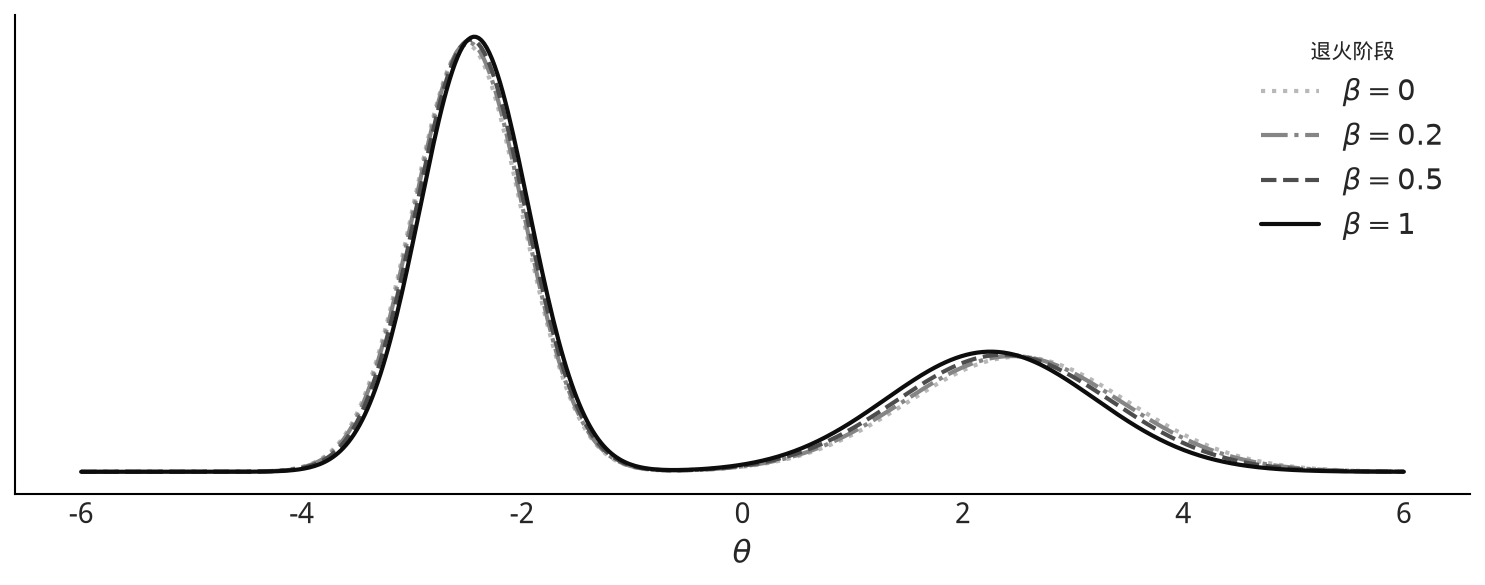

In [2]:
prior_left = stats.norm(-2.5, 0.5)
prior_right = stats.norm(2.5, 1)
likelihood_proxy = stats.norm(0, 3)
x = np.linspace(-6, 6, 500)

mixture_prior = 0.65 * prior_left.pdf(x) + 0.35 * prior_right.pdf(x)
likelihood_values = likelihood_proxy.pdf(x)
betas = (0, 0.2, 0.5, 1)
grays = ("0.72", "0.52", "0.30", "0.05")
line_styles = (":", "-.", "--", "-")

_, ax = plt.subplots(figsize=(10, 4))
for beta, gray, line_style in zip(betas, grays, line_styles):
    tempered = mixture_prior * likelihood_values**beta
    tempered /= np.trapezoid(tempered, x)
    ax.plot(
        x,
        tempered,
        color=gray,
        linestyle=line_style,
        linewidth=2,
        label=fr"$\beta={beta}$",
    )
ax.set(yticks=[], xlabel=r"$\theta$")
ax.legend(title="退火阶段")
plt.tight_layout()
plt.savefig(FIG_DIR / "smc_tempering.png")


```{figure} img/chp08/smc_tempering.png
:name: fig:smc_tempering
:width: 8.00in
SMC 采样器探索的假想退火后验序列：从浅灰色先验（$\beta=0$）到深色实际后验
（$\beta=1$）。开始阶段较低的 $\beta$ 有助于避免采样器困在单个极大值附近。
```


(fitting-a-gaussian-the-abc-way)=

## 用 ABC 拟合高斯分布

先从简单例子热身：数据来自均值 0、标准差 1 的高斯分布，我们要估计它的均值和
标准差。模型为：

```{math}
:label: eq:Gauss_model
\begin{split}
\boldsymbol{\mu} &\sim \mathcal{N}(0, 1) \\
\boldsymbol{\sigma} &\sim \mathcal{HN}(1) \\
\boldsymbol{s} &\sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\sigma})
\end{split}
```

若似然可显式计算，直接的当前 PyMC 写法如下。原版代码块
[gauss_nuts](gauss_nuts) 使用 `trace`；中文版改用 `InferenceData`：

(gauss_nuts)=
```python
with pm.Model() as gauss_nuts:
    μ = pm.Normal("μ", mu=0, sigma=1)
    σ = pm.HalfNormal("σ", sigma=1)
    s = pm.Normal("s", μ, σ, observed=data)
    idata_gauss_nuts = pm.sample(
        draws=NUTS_DRAWS, tune=NUTS_TUNE, chains=CHAINS,
        random_seed=RANDOM_SEED,
    )
```

等价的 SMC-ABC 模型见代码块 [gauss_abc](gauss_abc)。


In [3]:
DATA_SIZE = 1000
data = rng.normal(loc=0, scale=1, size=DATA_SIZE)

def normal_simulator(rng, mu, sigma, size=None):
    # 当前 pm.Simulator 回调：rng 为首参，size 由 PyMC 传入。
    if size is None:
        size = DATA_SIZE
    return rng.normal(mu, sigma, size=size)


In [4]:
with pm.Model() as gauss:
    μ = pm.Normal("μ", mu=0, sigma=1)
    σ = pm.HalfNormal("σ", sigma=1)
    s = pm.Simulator(
        "s",
        normal_simulator,
        params=[μ, σ],
        distance="gaussian",
        sum_stat="sort",
        epsilon=1,
        observed=data,
    )
    idata_g = pm.sample_smc(
        draws=SMC_DRAWS,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED,
    )


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

代码块 [gauss_nuts](gauss_nuts) 与 [gauss_abc](gauss_abc) 有两个关键区别：

- 后者使用 `pm.Simulator` 分布；
- 后者使用 `pm.sample_smc()`，而不是 `pm.sample()` 的梯度采样器。

`pm.Simulator` 告诉 PyMC：这里不使用闭式似然，而由伪似然代替。我们向它传入生成
合成数据的 Python 函数及参数。本例的 [normal_simulator](normal_simulator) 生成
样本量为 1000、未知参数为 $\mu$ 和 $\sigma$ 的数据。模拟器还可接受距离函数
`distance`、摘要统计量 `sum_stat` 和容忍度 `epsilon`；后文会详细讨论。与普通
似然一样，观测数据也传给该分布。

> **中文版 API 现代化。** 原版通过 `pm.sample_smc(kernel="ABC")` 明确选择旧
> PyMC3 ABC 内核[^3]。当前 PyMC 的 `Simulator` 定义伪似然，`sample_smc()` 会
> 直接使用它。其他依赖可微对数密度的采样器不能直接处理 `Simulator`。

模拟器原则上可以是任意 Python 函数，也可封装 Fortran 或 C 代码；这正是 ABC 的
灵活性所在。本例只是对 NumPy 随机生成器的轻量封装。

和其他采样器一样，建议运行不止一条链，以诊断采样是否失败。PyMC 会尽可能自动
完成这一点。{numref}`fig:trace_g` 是两条以上链的结果：真实参数得到恢复，未显示
明显采样问题。每条原书链由 2000 个并行 SMC 粒子得到；中文版 `release` 配置保留
该预算，`smoke` 配置只用于快速接口检查，不能用于推断结论。


In [5]:
az.summary(idata_g, var_names=["μ", "σ"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ,-0.015,0.045,-0.100,0.068,0.001,0.0,7512.0,7075.0,1.0
σ,0.991,0.039,0.918,1.062,0.000,0.0,8085.0,7670.0,1.0


/tmp/ipykernel_977548/2293911922.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


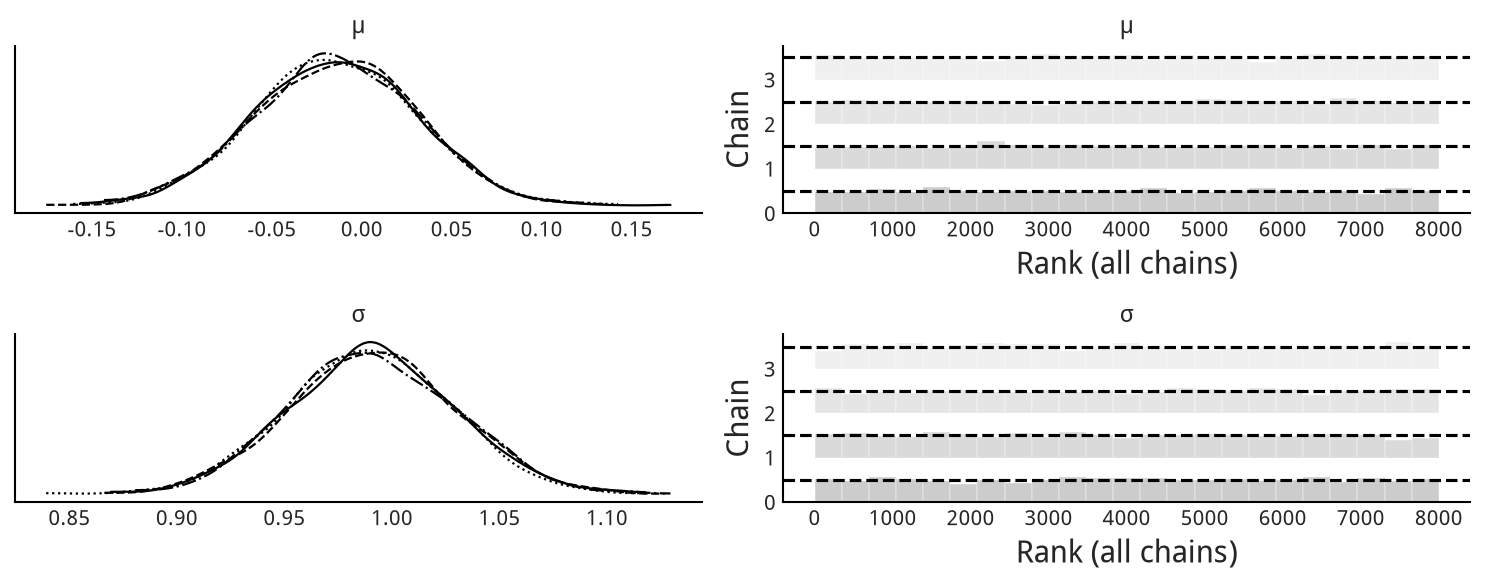

In [6]:
az.plot_trace(idata_g, var_names=["μ", "σ"], kind="rank_bars", figsize=(10, 4))
plt.tight_layout()
plt.savefig(FIG_DIR / "trace_g.png")


```{figure} img/chp08/trace_g.png
:name: fig:trace_g
:width: 8.00in
如预期，$\mu\approx0$ 且 $\sigma\approx1$。各条链的核密度估计和秩图都对后验
给出一致结论。原书图中的每条链由 2000 个并行 SMC 粒子得到。
```


(choosing-the-distance-function-epsilon-and-the-summary-statistics)=

## 选择距离函数、$\epsilon$ 与摘要统计量

有用的距离、摘要统计量和 $\epsilon$ 都依赖具体问题，因此在新问题中通常要经历
一些试错。事先思考合理选项能缩小搜索范围，但实验同样重要：它帮助我们理解问题，
并对这些超参数作出更有依据的选择。以下各节给出一般性指南。

(choosing-the-distance)=

### 选择距离

代码块 [gauss_abc](gauss_abc) 使用默认的高斯距离
`distance="gaussian"`：

```{math}
:label: eq:euclidean_abc
\sum_i -\frac{\lVert X_{oi}-X_{si}\rVert^2}{2\epsilon_i^2}
```

其中 $X_o$ 是观测数据，$X_s$ 是模拟数据，$\epsilon$ 是尺度参数。公式
{eq}`eq:euclidean_abc` 称为“高斯”距离，因为它是对数尺度上的高斯核[^4]。
和真实似然及先验一样，伪似然也在对数尺度上计算[^5]。其中的平方范数是欧氏距离
（L2 范数），所以该式也可称为加权欧氏距离。这是文献中的常见选择。

其他常用选项包括 L1 范数（绝对差之和，在 PyMC 中称为 Laplace 距离）、
L$\infty$ 范数（绝对差的最大值）以及 Mahalanobis 距离
$\sqrt{(x_o-x_s)^T\Sigma^{-1}(x_o-x_s)}$，其中 $\Sigma$ 是协方差矩阵、
$\Sigma^{-1}$ 是其逆矩阵。

高斯、Laplace 等距离既能作用于全部数据，也能作用于摘要统计量。还有一些距离专门
为避免摘要统计量而提出，并仍能提供良好结果
{cite:p}`Perez2008, Jiang2018, Bernton_2019`。下面讨论 Wasserstein 距离和
KL 散度。

在 [gauss_abc](gauss_abc) 中，`sum_stat="sort"`[^6] 会在计算
{eq}`eq:euclidean_abc` 前排序数据。这样配合 L2 范数等价于一维 2-Wasserstein
距离；若改用 L1 范数，则是一维 1-Wasserstein 距离。Wasserstein 距离也可定义
在高于一维的情形 {cite:p}`Bernton_2019`。

先排序会让分布比较更公平。设两个样本值完全相同，只因偶然一个从小到大排列、另
一个从大到小排列；若直接计算欧氏距离，会误判它们差异很大，排序后则会判定相同。
这是极端情形，却能说明直觉。与此同时，排序意味着我们只关心分布而不关心数据顺
序；若顺序含有结构，排序会破坏它，例如时间序列（见[第 6 章](chap4)）。

另一种避免预先定义摘要统计量的方法是 KL 散度（见 {ref}`DKL`）。可用下式近似
{cite:p}`Perez2008, Jiang2018`：

```{math}
:label: eq:kl_abc
\frac{d}{n}\sum\left[-\frac{\log(\nu_d/\rho_d)}{\epsilon}\right]
+\log\left(\frac{n}{n-1}\right)
```

$d$ 是数据维数（变量或特征数），$n$ 是观测点数；$\nu_d$ 包含观测数据到模拟
数据的 1-近邻距离，$\rho_d$ 包含观测数据到自身的 2-近邻距离。数据与自身比较时，
1-近邻总是自身、距离为零，所以这里使用 2-近邻。该方法要进行约 $2n$ 次近邻搜索，
通常借助 k-d 树实现 {cite:p}`Bentley1975`。


(choosing-epsilon)=

### 选择 $\epsilon$

在许多 ABC 方法中，$\epsilon$ 是硬阈值：生成样本的距离大于它时，参数 $\theta$
会被拒绝。$\epsilon$ 也可以是一列递减值，由用户设定或算法自适应寻找[^7]。

在 PyMC 中，$\epsilon$ 是距离函数的尺度，例如公式 {eq}`eq:euclidean_abc` 中的
尺度，而不是硬阈值。可以按问题需要设置它。若直接在数据上计算距离，可使用标量
（相当于所有 $\epsilon_i$ 相等）；一个有依据的初始猜测是数据的经验标准差。

若使用多个摘要统计量，通常需要给出一组 $\epsilon$，因为各摘要可能有不同尺度。
尺度差异太大时，各统计量对距离的贡献会失衡，甚至由一个摘要完全支配。常见选择是
先验预测分布下第 $i$ 个摘要统计量的经验标准差，或对离群值更稳健的中位数绝对
偏差。不过，先验预测可能比后验预测宽得多。因此可把这些有依据的猜测当作上界，
再尝试几个更小的值，并综合计算成本、所需精度、近似误差和采样效率确定最终
$\epsilon$。一般而言，$\epsilon$ 越小，近似越精确。

{numref}`fig:trace_g_many_eps` 比较了 $\epsilon=1,5,10$ 时 $\mu,\sigma$ 的
森林图，并加入使用显式正态似然的 NUTS 结果。


In [7]:
def fit_gaussian_abc(epsilon, seed):
    with pm.Model() as model:
        μ = pm.Normal("μ", mu=0, sigma=1)
        σ = pm.HalfNormal("σ", sigma=1)
        s = pm.Simulator(
            "s",
            normal_simulator,
            params=[μ, σ],
            distance="gaussian",
            sum_stat="sort",
            epsilon=epsilon,
            observed=data,
        )
        idata = pm.sample_smc(
            draws=SMC_DRAWS,
            chains=CHAINS,
            cores=1,
            random_seed=seed,
        )
        idata.extend(
            pm.sample_posterior_predictive(
                idata,
                random_seed=seed + 10_000,
                progressbar=False,
            )
        )
    return model, idata

gauss_001, idata_g_001 = fit_gaussian_abc(0.1, RANDOM_SEED + 1)
gauss_01, idata_g_01 = fit_gaussian_abc(1, RANDOM_SEED + 2)
gauss_02, idata_g_02 = fit_gaussian_abc(2, RANDOM_SEED + 3)
gauss_05, idata_g_05 = fit_gaussian_abc(5, RANDOM_SEED + 4)
gauss_10, idata_g_10 = fit_gaussian_abc(10, RANDOM_SEED + 5)

with pm.Model() as gauss_NUTS:
    μ = pm.Normal("μ", mu=0, sigma=1)
    σ = pm.HalfNormal("σ", sigma=1)
    s = pm.Normal("s", μ, σ, observed=data)
    idata_g_nuts = pm.sample(
        draws=NUTS_DRAWS,
        tune=NUTS_TUNE,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 6,
        progressbar=False,
    )


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


...

Output()

Sampling: [s]


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

/tmp/ipykernel_977548/2416541536.py:8: UserWarning: Glyph 1013 (\N{GREEK LUNATE EPSILON SYMBOL}) missing from font(s) WenQuanYi Micro Hei.
  plt.tight_layout()
/tmp/ipykernel_977548/2416541536.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 1013 (\N{GREEK LUNATE EPSILON SYMBOL}) missing from font(s) WenQuanYi Micro Hei.
  fig.canvas.print_figure(bytes_io, **kw)


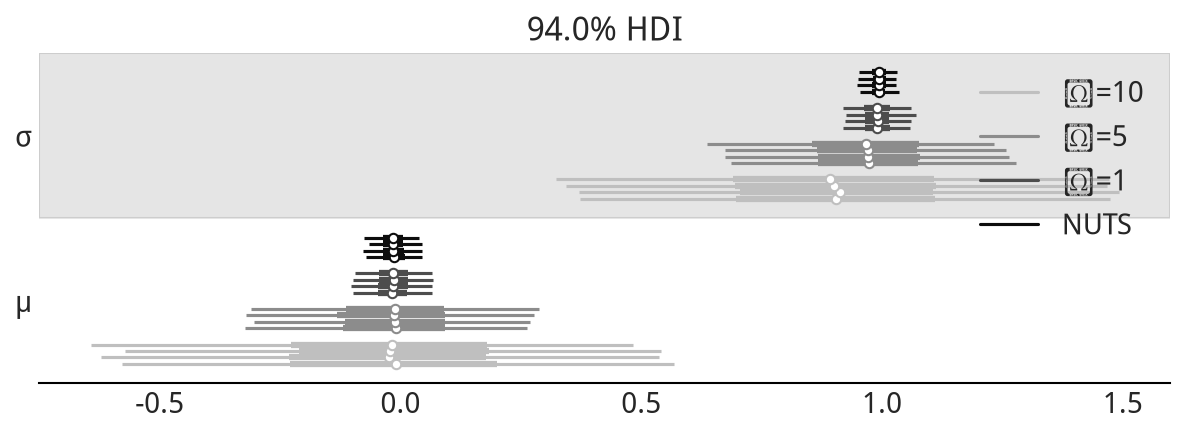

In [8]:
epsilon_idatas = [idata_g_nuts, idata_g_01, idata_g_05, idata_g_10]
az.plot_forest(
    epsilon_idatas,
    model_names=["NUTS", "ϵ=1", "ϵ=5", "ϵ=10"],
    colors=["0.05", "0.30", "0.55", "0.75"],
    figsize=(8, 3),
)
plt.tight_layout()
plt.savefig(FIG_DIR / "trace_g_many_eps.png")


```{figure} img/chp08/trace_g_many_eps.png
:name: fig:trace_g_many_eps
:width: 8.00in
$\mu$ 与 $\sigma$ 的森林图：比较 NUTS 与逐渐增大的 $\epsilon=1,5,10$。
```

减小 $\epsilon$ 也有极限。值过低会使采样器效率极差，这通常表示我们追求了不合
理的精度。{numref}`fig:trace_g_eps_too_low` 展示
[gauss_abc](gauss_abc) 在 `epsilon=0.1` 时无法收敛的情形；失败十分明显。


/tmp/ipykernel_977548/737477861.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


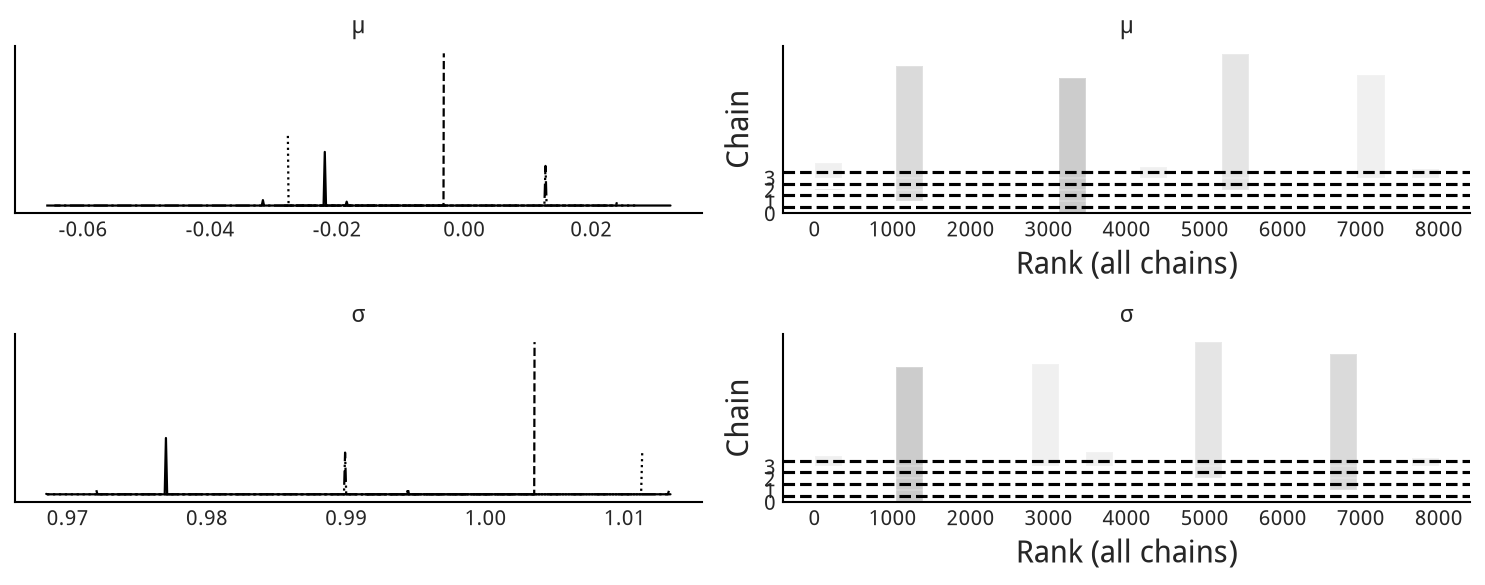

In [9]:
az.plot_trace(
    idata_g_001,
    var_names=["μ", "σ"],
    kind="rank_bars",
    figsize=(10, 4),
)
plt.tight_layout()
plt.savefig(FIG_DIR / "trace_g_eps_too_low.png")


```{figure} img/chp08/trace_g_eps_too_low.png
:name: fig:trace_g_eps_too_low
:width: 8.00in
`idata_g_001` 的 KDE 与秩图。收敛失败提示，对这个问题而言
$\epsilon=0.1$ 过低。
```

可利用非 ABC 模型中已经使用过的模型批判工具选择 $\epsilon$，例如边际贝叶斯
p 值和后验预测检验，见 {numref}`fig:bpv_g_many_eps_00`、
{numref}`fig:bpv_g_many_eps_01` 与 {numref}`fig:ppc_g_many_eps`。
第一幅图故意保留 $\epsilon=0.1$，以展示校准很差的模型。实践中若得到
{numref}`fig:trace_g_eps_too_low` 那样的秩图，应立即停止解释后验，重新检查模型；
对 ABC 还要检查 $\epsilon$、摘要统计量和距离函数。


/tmp/ipykernel_977548/3440305833.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


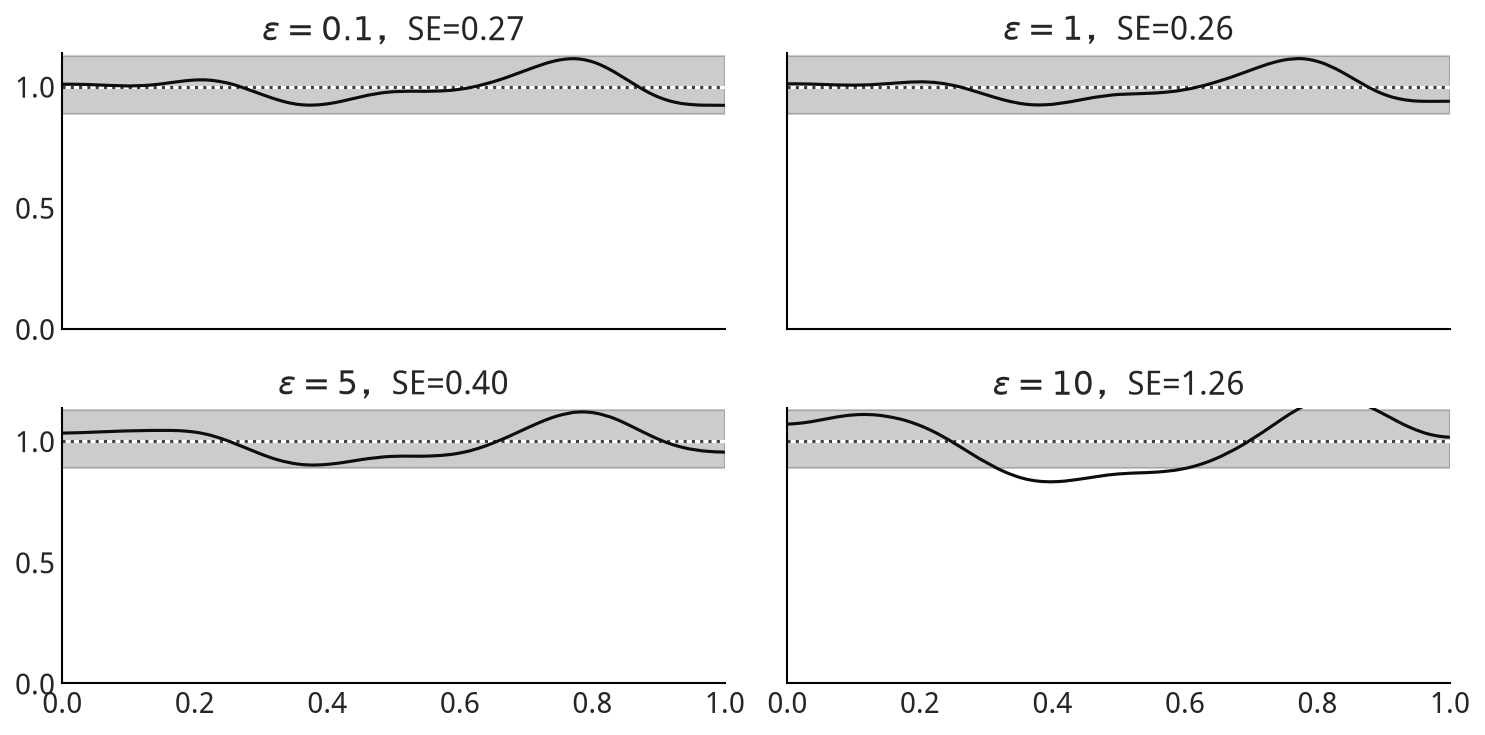

In [10]:
idatas_by_epsilon = [idata_g_001, idata_g_01, idata_g_05, idata_g_10]
epsilons = [0.1, 1, 5, 10]

def posterior_predictive_matrix(idata, variable):
    values = idata.posterior_predictive[variable]
    sample_dims = [dim for dim in ("chain", "draw", "sample") if dim in values.dims]
    if sample_dims == ["sample"]:
        normalized = values
    else:
        normalized = values.stack(sample=sample_dims)
    event_dims = [dim for dim in normalized.dims if dim != "sample"]
    normalized = normalized.transpose("sample", *event_dims)
    return np.asarray(normalized).reshape(normalized.sizes["sample"], -1)

_, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
for epsilon, idata, ax in zip(epsilons, idatas_by_epsilon, axes.ravel()):
    pp_values = posterior_predictive_matrix(idata, "s")
    pit = np.mean(pp_values <= data.reshape(1, -1), axis=0)
    _, pit_density = az.kde(pit)
    scaled_squared_error = np.mean((1 - pit_density) ** 2) * 100

    ax.axhline(1, color="0.25", linestyle=":", linewidth=1.5)
    az.plot_bpv(idata, kind="u_value", ax=ax, reference="analytical", color="0.05")
    ax.set_title(fr"$\epsilon={epsilon}$，SE={scaled_squared_error:.2f}")
plt.tight_layout()
plt.savefig(FIG_DIR / "bpv_g_many_eps_00.png")


```{figure} img/chp08/bpv_g_many_eps_00.png
:name: fig:bpv_g_many_eps_00
:width: 8.00in
随 $\epsilon$ 增大的边际贝叶斯 p 值分布。校准良好的模型应接近均匀分布。
$\epsilon=0.1$ 的校准很差，这并不意外，因为该值过低；其余值更接近均匀，且
均匀性随 $\epsilon$ 增大而下降。`SE` 是期望均匀密度与估计 KDE 之间经缩放的
平方差。
```


/tmp/ipykernel_977548/136510809.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


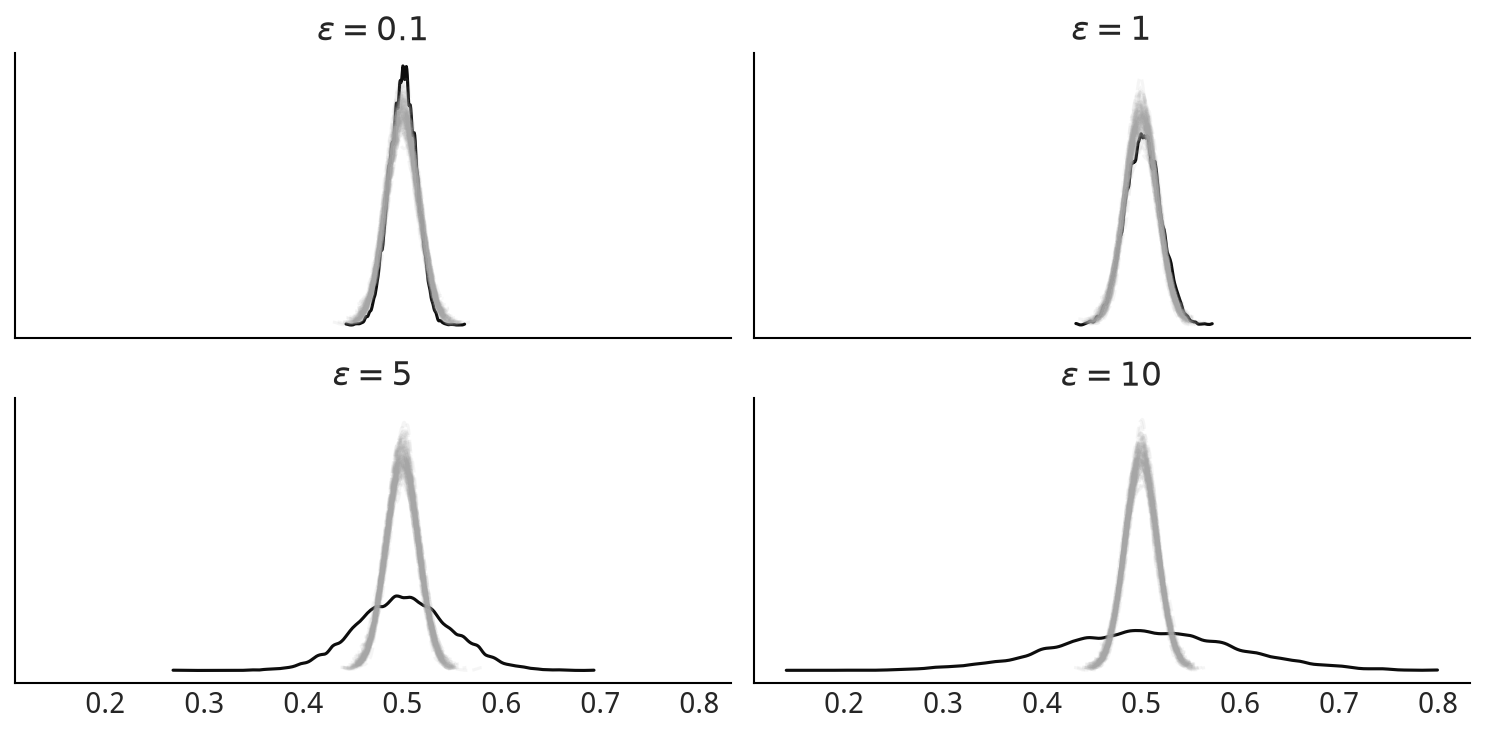

In [11]:
_, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
for epsilon, idata, ax in zip(epsilons, idatas_by_epsilon, axes.ravel()):
    az.plot_bpv(
        idata,
        kind="p_value",
        reference="samples",
        color="0.05",
        ax=ax,
        plot_ref_kwargs={"color": "0.65", "linestyle": "--"},
    )
    ax.set_title(fr"$\epsilon={epsilon}$")
plt.tight_layout()
plt.savefig(FIG_DIR / "bpv_g_many_eps_01.png")


```{figure} img/chp08/bpv_g_many_eps_01.png
:name: fig:bpv_g_many_eps_01
:width: 8.00in
随 $\epsilon$ 增大的贝叶斯 p 值。深色曲线为观测分布，浅灰虚线为参考分布。
校准良好时，分布应集中在 0.5 附近。$\epsilon=0.1$ 的校准很差；本例中
$\epsilon=1$ 表现最好。
```


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/plots/ppcplot.py:242: FutureWarning: color has been deprecated in favor of colors
  warnings.warn("color has been deprecated in favor of colors", FutureWarning)


/tmp/ipykernel_977548/3332618733.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


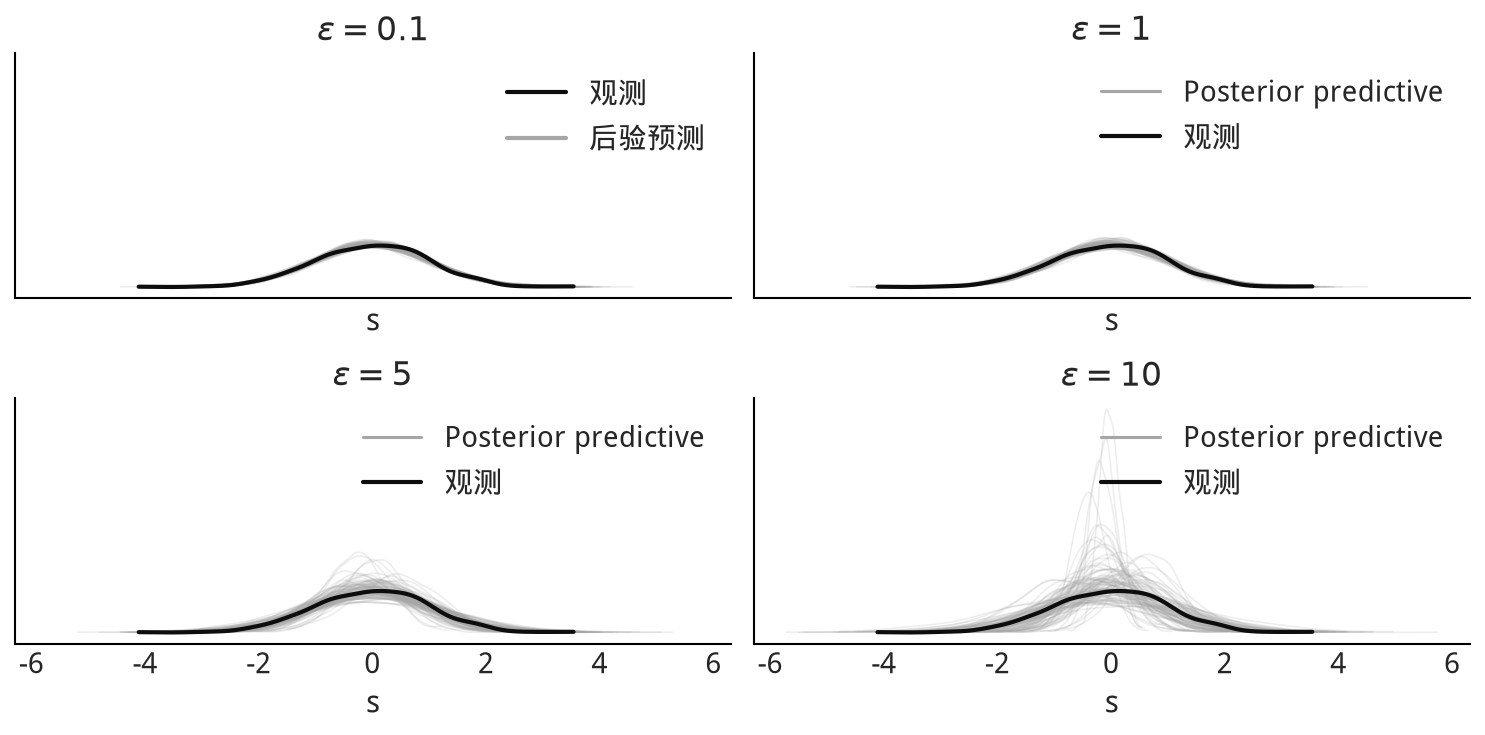

In [12]:
_, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
for epsilon, idata, ax in zip(epsilons, idatas_by_epsilon, axes.ravel()):
    az.plot_ppc(
        idata,
        num_pp_samples=min(PPC_SAMPLES, idata.posterior.sizes["draw"] * CHAINS),
        ax=ax,
        color="0.65",
        mean=False,
        legend=False,
        observed=False,
        random_seed=RANDOM_SEED,
    )
    az.plot_kde(
        np.asarray(idata.observed_data["s"]),
        plot_kwargs={"color": "0.05", "linewidth": 2, "label": "观测"},
        ax=ax,
    )
    ax.set(xlabel="s", title=fr"$\epsilon={epsilon}$")
handles = [
    plt.Line2D([], [], color="0.05", linewidth=2, label="观测"),
    plt.Line2D([], [], color="0.65", linewidth=2, label="后验预测"),
]
axes[0, 0].legend(handles=handles)
plt.tight_layout()
plt.savefig(FIG_DIR / "ppc_g_many_eps.png")


```{figure} img/chp08/ppc_g_many_eps.png
:name: fig:ppc_g_many_eps
:width: 8.00in
随 $\epsilon$ 增大的后验预测检验。深色曲线是观测分布，灰色曲线是预测分布。
令人意外的是，$\epsilon=0.1$ 看起来也拟合良好，尽管我们知道该后验样本不可信；
这个简单例子纯属偶然得到正确答案，是“好得不真实”的拟合，而这种情形最危险。
若只考虑后验样本看起来合理的模型，$\epsilon=1$ 表现最好。
```


(choosing-summary-statistics)=

### 选择摘要统计量

摘要统计量的选择可以说比距离函数更困难，影响也更大。因此大量研究围绕这一主题，
从不需要摘要的距离 {cite:p}`Jiang2018, Bernton_2019` 到摘要选择策略
{cite:p}`Sisson2018`。

好的摘要统计量在低维与信息量之间取得平衡。没有充分摘要时，人们很容易加入大量
摘要来补偿，直觉是“信息越多越好”；但增加摘要统计量反而可能降低近似后验质量
{cite:p}`Sisson2018`。我们原本从比较数据改为比较摘要，就是为了降维；摘要数量
太多会抵消这一目的。

在群体遗传学等经常使用 ABC 的领域，人们已经发展出大量有用摘要
{cite:p}`Beaumont2002, Beaumont2010, Pudlo2015`。通常应先查阅所属应用领域的
文献，因为前人很可能已经测试过许多方案。

有疑问时，可沿用上一节的模型拟合评估：秩图、贝叶斯 p 值、后验预测检验等；必要
时尝试替代方案（见 {numref}`fig:trace_g_eps_too_low`、
{numref}`fig:bpv_g_many_eps_00`、{numref}`fig:bpv_g_many_eps_01` 和
{numref}`fig:ppc_g_many_eps`）。


(g-and-k-distribution)=

## g-and-k 分布

一氧化碳（CO）是无色无味的气体，大量吸入会有害甚至致命。它在物质燃烧时产生，
尤其是氧气不足时。世界许多城市会监测 CO、二氧化氮（NO₂）等气体，以评估空气
污染和空气质量。城市中的 CO 主要来自汽车，以及其他燃烧化石燃料的车辆和机械。

{numref}`fig:co_ppm_bsas` 是布宜诺斯艾利斯某监测站 2010—2018 年每日 CO 水平的
直方图。数据略微右偏，还有少数非常高的观测；下方面板省略了 3 到 30 之间的 8 个
观测。


In [13]:
pollution = pd.read_csv(DATA_DIR / "air_pollution_bsas.csv")
bsas_co = pollution["co"].dropna().to_numpy()


/tmp/ipykernel_977548/3332204589.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


大于 3 ppm 的观测数：8


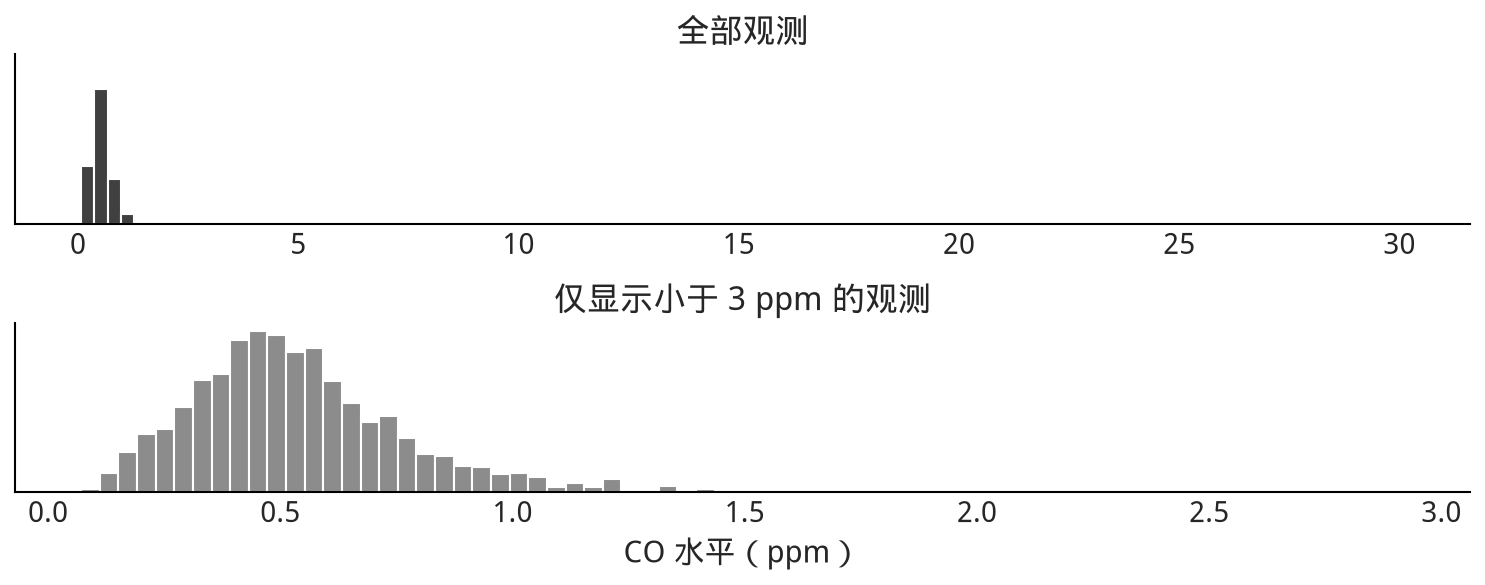

In [14]:
_, axes = plt.subplots(2, 1, figsize=(10, 4), sharey=True)
axes[0].hist(bsas_co, bins="auto", color="0.25", edgecolor="white", density=True)
axes[1].hist(
    bsas_co[bsas_co < 3],
    bins="auto",
    color="0.55",
    edgecolor="white",
    density=True,
)
for ax in axes:
    ax.set_yticks([])
axes[1].set_xlabel("CO 水平（ppm）")
axes[0].set_title("全部观测")
axes[1].set_title("仅显示小于 3 ppm 的观测")
plt.tight_layout()
plt.savefig(FIG_DIR / "co_ppm_bsas.png")
print(f"大于 3 ppm 的观测数：{np.sum(bsas_co > 3)}")


```{figure} img/chp08/co_ppm_bsas.png
:name: fig:co_ppm_bsas
:width: 8.00in
CO 水平直方图。上方面板显示全部数据，下方面板省略大于 3 的值。
```

为拟合这些数据，我们引入单变量 g-and-k 分布。它有四个参数，可描述高偏度和/或
高峰度的数据 {cite:p}`Tukey1977, Rayner2002`。其密度函数没有闭式表达，分布由
分位数函数（即累积分布函数的逆）定义：

```{math}
:label: eq:g_and_k
a+b\left(1+c\tanh\left[\frac{g z(x)}{2}\right]\right)
\left(1+z(x)^2\right)^kz(x)
```

其中 $z$ 是标准正态累积分布函数的逆，$x\in(0,1)$。

参数 $a,b,g,k$ 分别控制位置、尺度、偏度和峰度。若 $g=k=0$，就恢复均值为 $a$、
标准差为 $b$ 的高斯分布。$g>0$ 表示正（右）偏，$g<0$ 表示负（左）偏；
$k\geq0$ 产生比正态更长的尾部，$k<0$ 产生更短的尾部。$a$ 和 $g$ 可取任意实数。
通常约束 $b>0$，并令 $k\geq-0.5$，有时进一步令 $k\geq0$；还常固定
$c=0.8$。在这些限制下，分位数函数严格递增 {cite:p}`Rayner2002`，这是定义良好
的连续分布函数应有的性质。

代码块 [gk_quantile](gk_quantile) 定义 g-and-k 分位数分布。CDF 和 PDF 的计算
更复杂，而且本例不需要，因此省略[^8]。虽然密度可数值求值
{cite:p}`Rayner2002, prangle2017`，使用逆变换法从模型模拟更直接、更快速
{cite:p}`Drovandi2011, prangle2017`：先抽取 $x\sim\mathcal U(0,1)$，再代入
{eq}`eq:g_and_k`。


In [15]:
class GAndKQuantile:
    # 仅实现本章需要的分位数函数与逆变换抽样。

    def ppf(self, probabilities, a, b, g, k):
        probabilities = np.asarray(probabilities)
        z = stats.norm.ppf(probabilities)
        return a + b * (1 + 0.8 * np.tanh(g * z / 2)) * (1 + z**2) ** k * z

    def rvs(self, rng, a, b, g, k, size):
        tiny = np.finfo(float).eps
        probabilities = rng.uniform(tiny, 1 - tiny, size=size)
        return self.ppf(probabilities, a, b, g, k)

gk = GAndKQuantile()


/tmp/ipykernel_977548/283793773.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


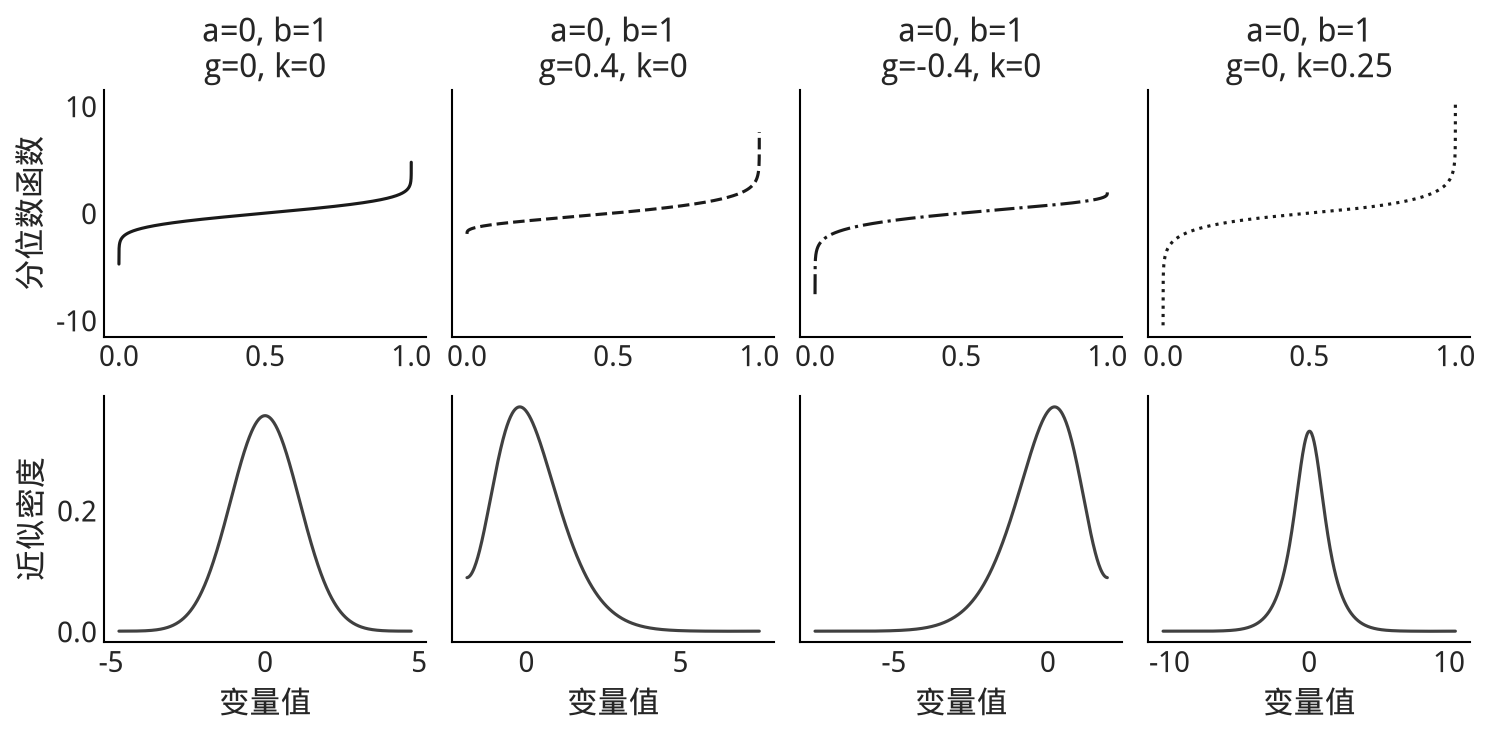

In [16]:
probabilities = np.linspace(1e-6, 1 - 1e-6, 10_000)
parameter_sets = (
    (0, 1, 0, 0),
    (0, 1, 0.4, 0),
    (0, 1, -0.4, 0),
    (0, 1, 0, 0.25),
)
line_styles = ("-", "--", "-.", ":")

_, axes = plt.subplots(2, 4, sharey="row", figsize=(10, 5))
for column, (parameters, line_style) in enumerate(zip(parameter_sets, line_styles)):
    a, b, g, k = parameters
    quantiles = gk.ppf(probabilities, a, b, g, k)
    axes[0, column].plot(probabilities, quantiles, color="0.10", linestyle=line_style)
    axes[0, column].set_title(f"a={a}, b={b}\ng={g}, k={k}")
    az.plot_kde(quantiles, ax=axes[1, column], bw=0.5, plot_kwargs={"color": "0.25"})
axes[0, 0].set_ylabel("分位数函数")
axes[1, 0].set_ylabel("近似密度")
for ax in axes[1]:
    ax.set_xlabel("变量值")
plt.tight_layout()
plt.savefig(FIG_DIR / "gk_quantile.png")


```{figure} img/chp08/gk_quantile.png
:name: fig:gk_quantile
:width: 8.00in
第一行是分位数函数（CDF 的逆）：输入分位概率，输出代表该分位数的变量值。例如
$P(X\le x_q)=q$ 时，输入 $q$ 得到 $x_q$。第二行是近似 PDF，由代码块
[gk_quantile](gk_quantile) 生成的随机样本经核密度估计得到。
```

使用 SMC-ABC 拟合 g-and-k 分布时，可像高斯例子那样使用 Gaussian 距离和
`sum_stat="sort"`；也可设计专门摘要。参数 $a,b,g,k$ 分别联系位置、尺度、偏度和
峰度，因此可使用这些量的稳健估计 {cite:p}`Drovandi2011`：

```{math}
:label: eq:octiles
\begin{split}
s_a &= e_4 \\
s_b &= e_6-e_2 \\
s_g &= (e_6+e_2-2e_4)/s_b \\
s_k &= (e_7-e_5+e_3-e_1)/s_b
\end{split}
```

$e_1$ 到 $e_7$ 是八分位数，即把样本分成八部分的分位点。$s_a$ 是中位数，
$s_b$ 是四分位距，分别是稳健的位置和离散程度估计。$s_g$ 与 $s_k$ 看似更晦涩，
但也分别是稳健偏度 {cite:p}`Bowley1920` 和峰度 {cite:p}`Moors1988` 估计。

对称分布中，$e_6-e_4$ 与 $e_2-e_4$ 大小相同、符号相反，所以 $s_g=0$；偏斜时
两者之一更大。$s_k$ 分子中的两项会在 $e_6$ 与 $e_2$ 邻域质量下降、即概率质量从
中心移向尾部时增大。$s_g$ 和 $s_k$ 的分母都是归一化因子。


In [17]:
def octo_summary(x):
    e1, e2, e3, e4, e5, e6, e7 = np.quantile(
        x, [0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875]
    )
    sa = e4
    sb = e6 - e2
    safe_sb = max(float(sb), np.finfo(float).eps)
    sg = (e6 + e2 - 2 * e4) / safe_sb
    sk = (e7 - e5 + e3 - e1) / safe_sb
    return np.array([sa, sb, sg, sk])


In [18]:
def gk_simulator(rng, a, b, g, k, size=None):
    if size is None:
        size = len(bsas_co)
    return gk.rvs(rng, a, b, g, k, size=size)


定义了摘要统计量和模拟器，并读入数据后，就可以建立模型。本例采用弱信息先验。
所有参数都限制为正：CO 水平不能为负，所以 $a>0$；常见水平预计较低、仅少数测量
较大，所以 $g$ 预计为 0 或正。我们也有理由认为这些参数大多小于 1。


In [19]:
with pm.Model() as gkm:
    a = pm.HalfNormal("a", sigma=1)
    b = pm.HalfNormal("b", sigma=1)
    g = pm.HalfNormal("g", sigma=1)
    k = pm.HalfNormal("k", sigma=1)

    s = pm.Simulator(
        "s",
        gk_simulator,
        params=[a, b, g, k],
        distance="gaussian",
        sum_stat=octo_summary,
        epsilon=0.1,
        observed=bsas_co,
    )
    idata_gk = pm.sample_smc(
        draws=SMC_DRAWS,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 20,
    )
    idata_gk.extend(
        pm.sample_posterior_predictive(
            idata_gk,
            random_seed=RANDOM_SEED + 21,
            progressbar=False,
        )
    )


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

Sampling: [s]


In [20]:
az.summary(idata_gk, var_names=["a", "b", "g", "k"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.501,0.100,0.320,0.698,0.001,0.001,6929.0,6739.0,1.0
b,0.197,0.070,0.066,0.328,0.001,0.001,7120.0,5505.0,1.0
g,0.451,0.285,0.008,0.951,0.003,0.003,7403.0,5720.0,1.0
k,0.145,0.088,0.002,0.293,0.001,0.001,5986.0,4408.0,1.0


/tmp/ipykernel_977548/3479342275.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


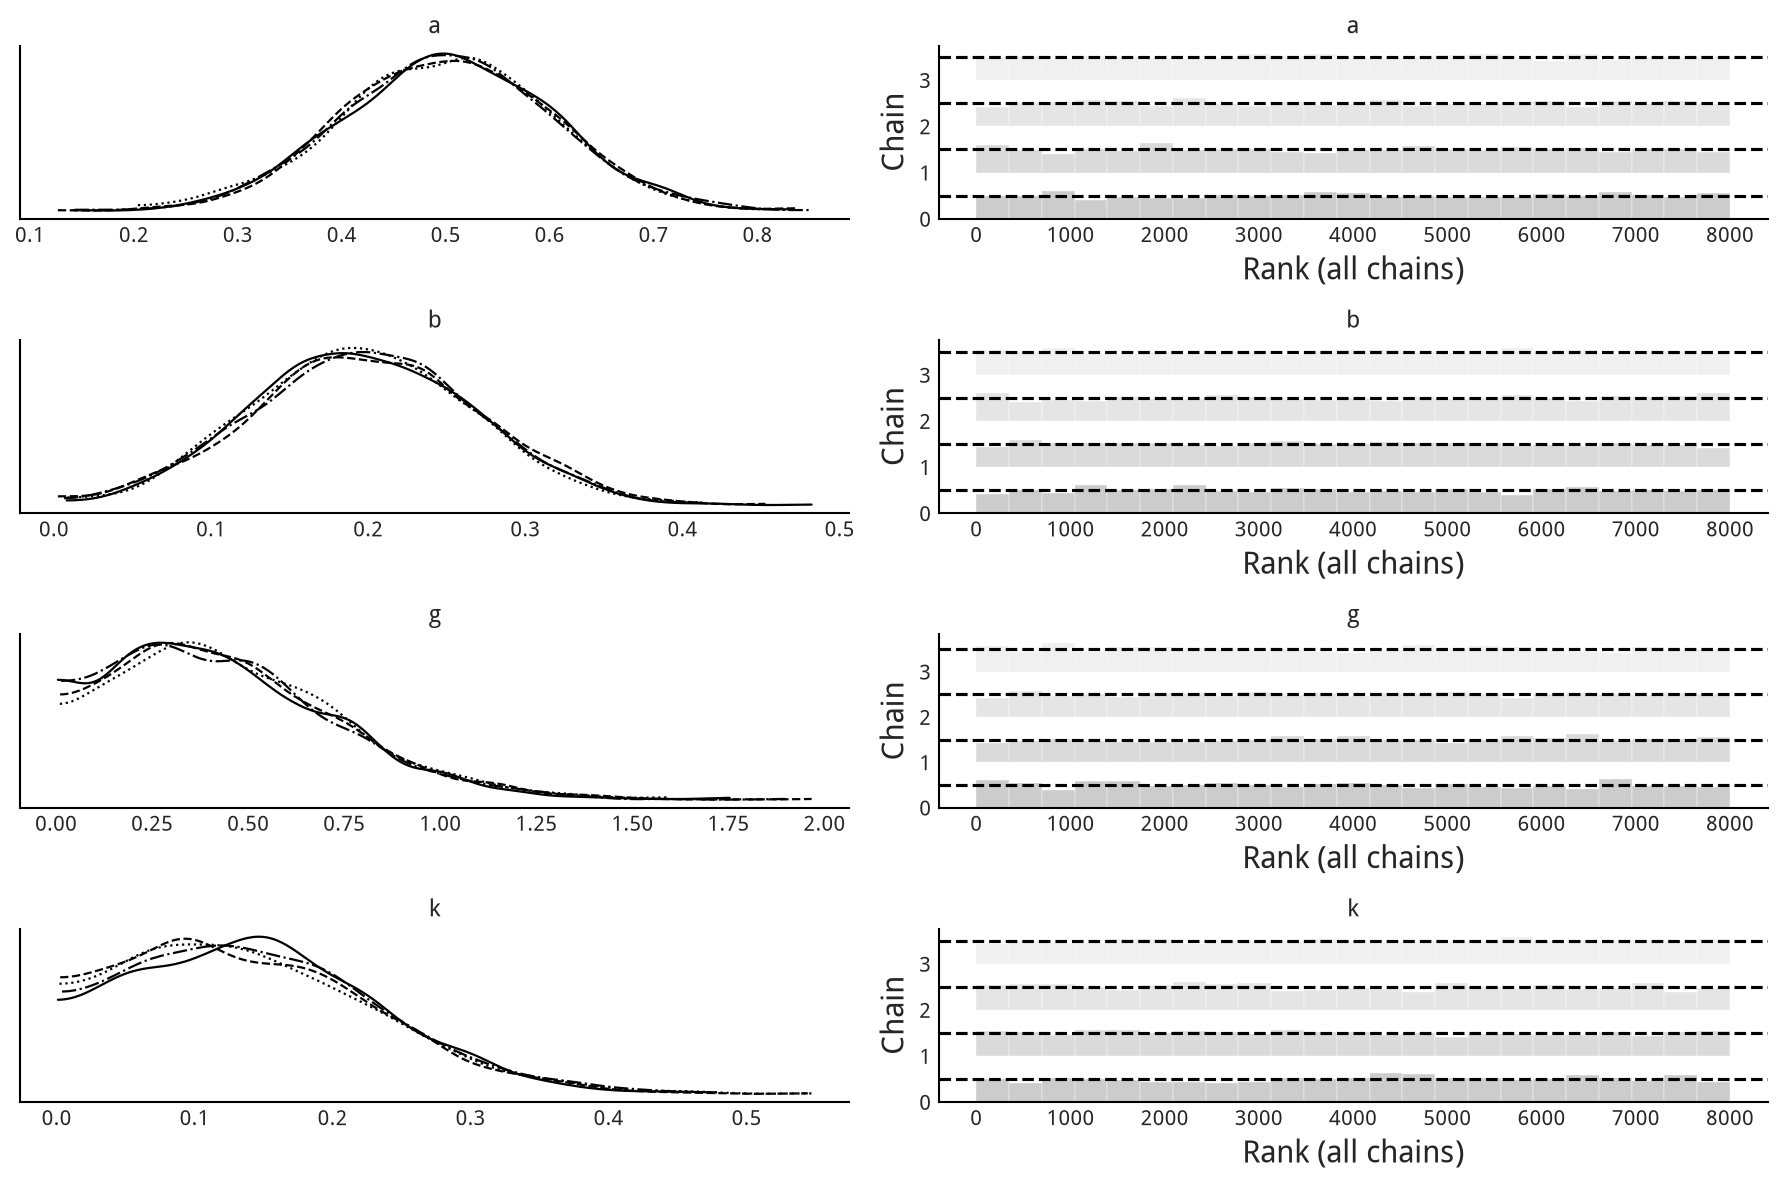

In [21]:
az.plot_trace(idata_gk, var_names=["a", "b", "g", "k"], kind="rank_bars")
plt.tight_layout()
plt.savefig(FIG_DIR / "trace_gk.png")


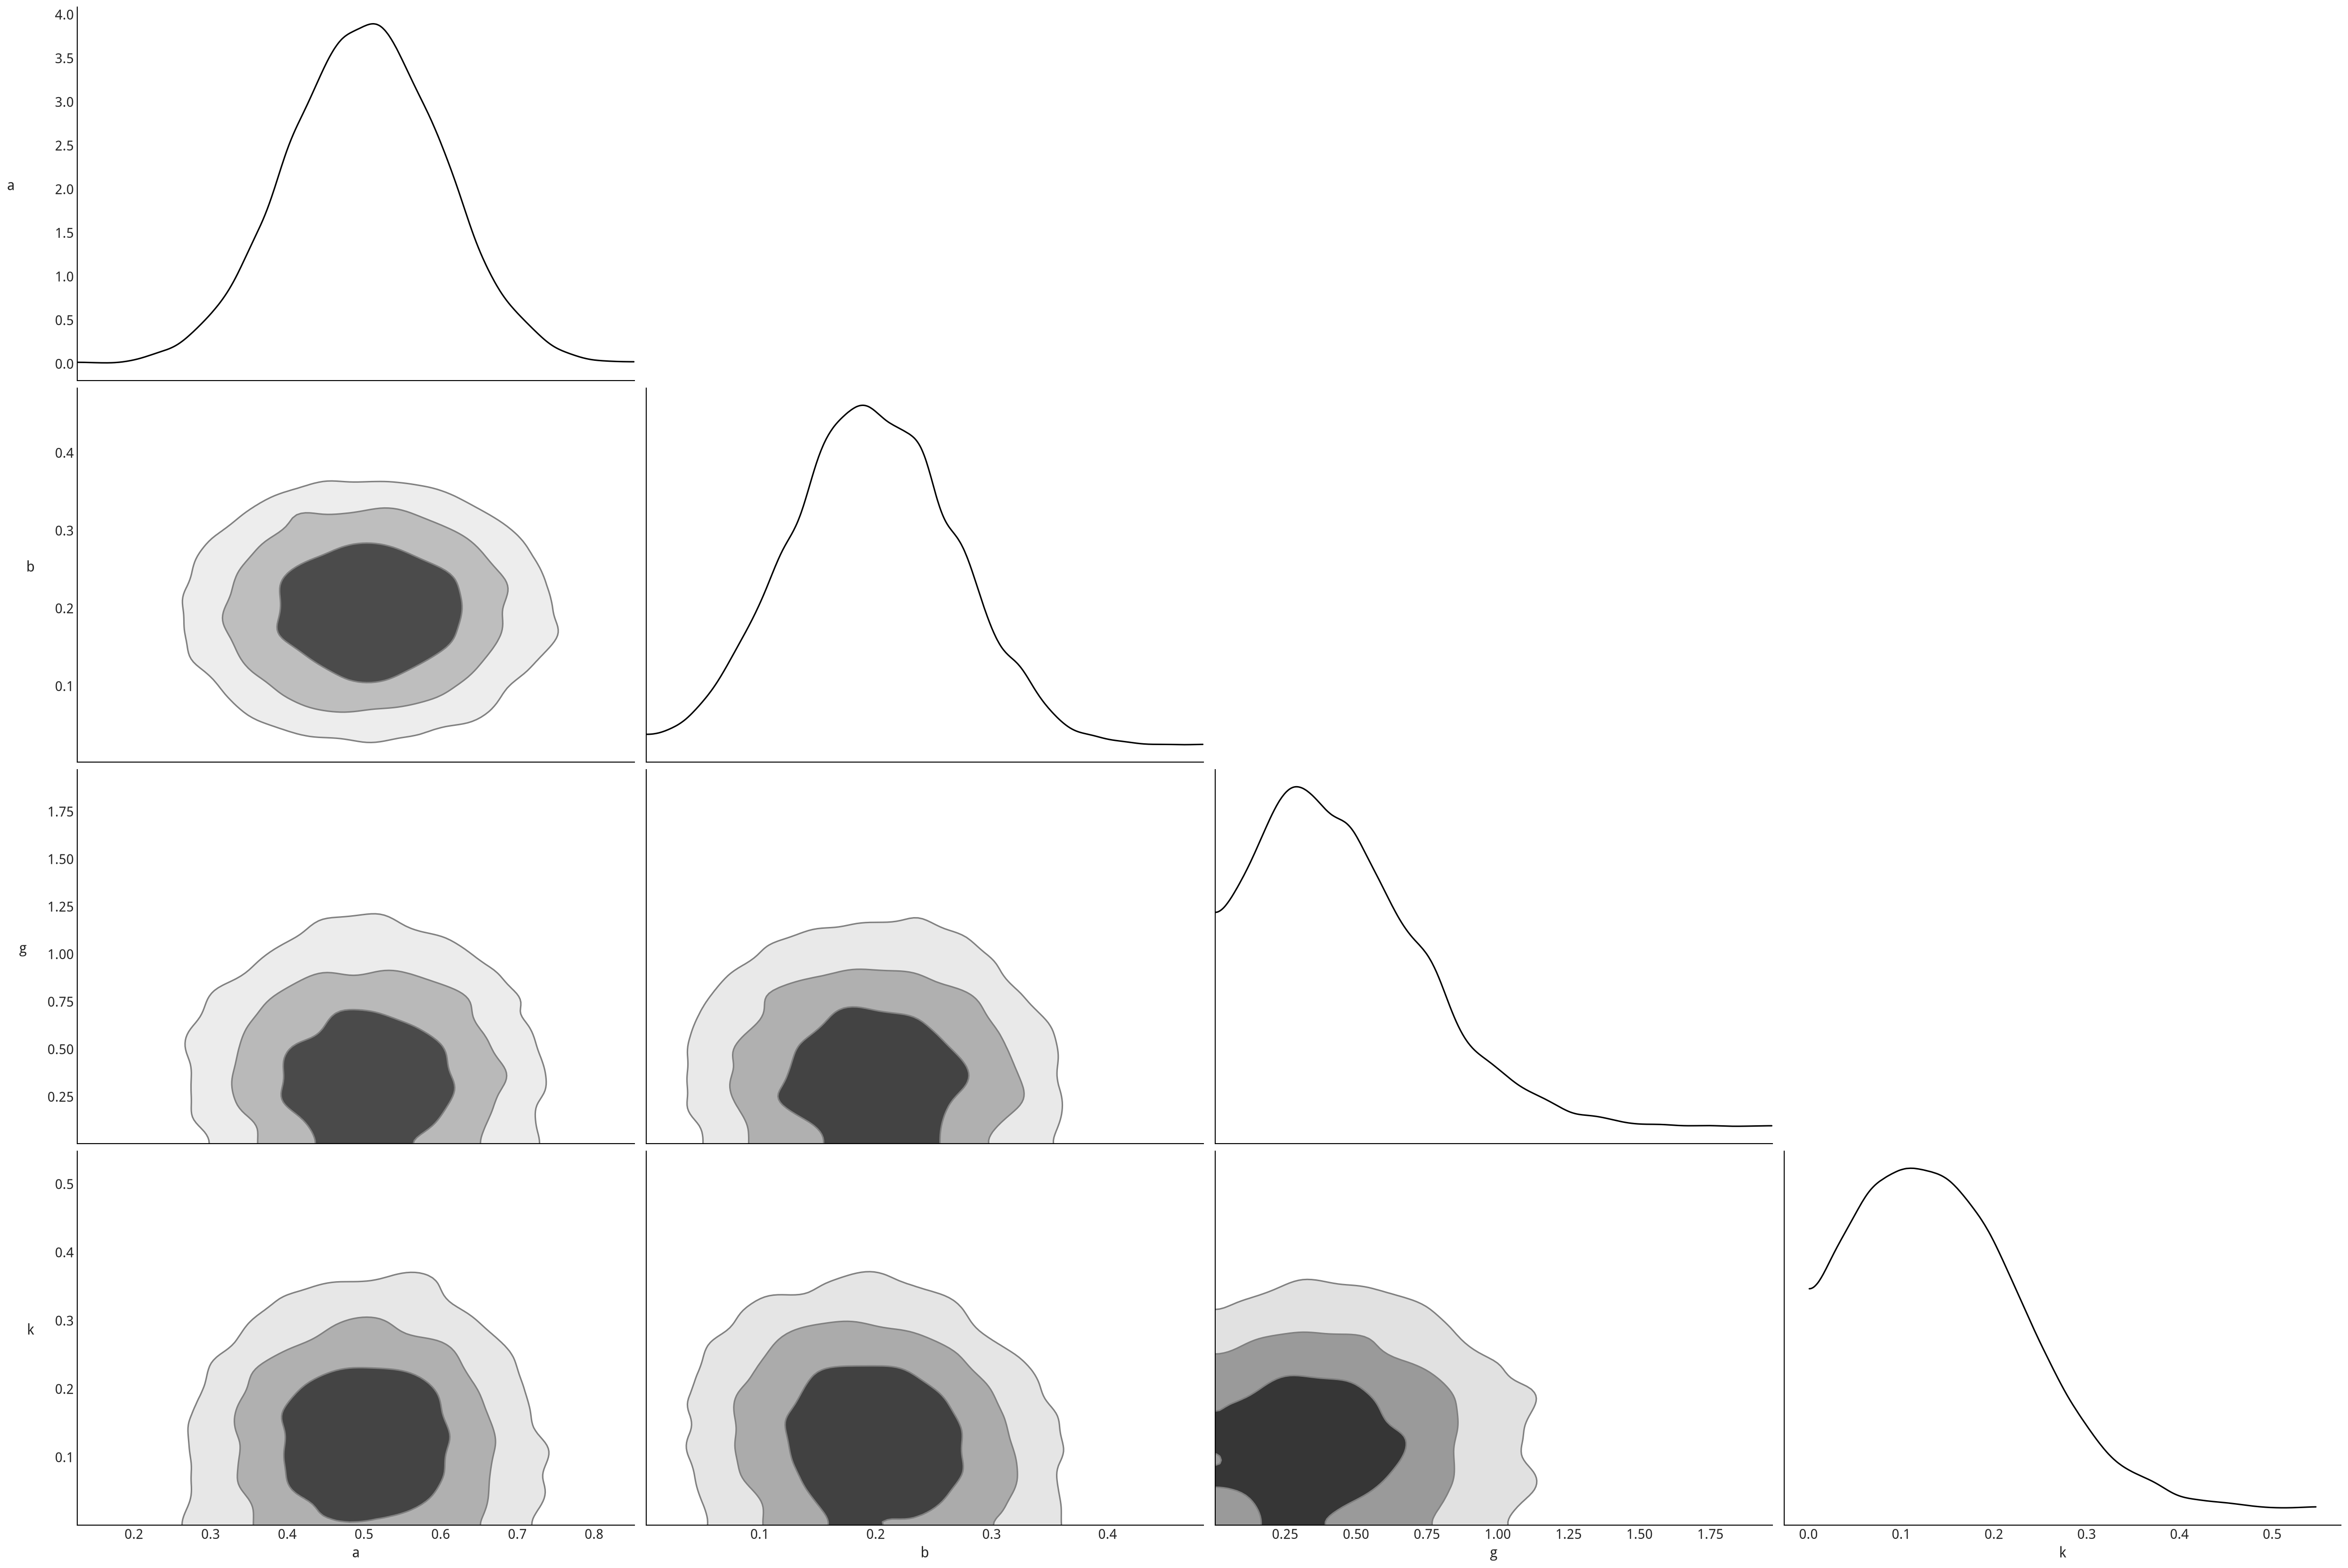

In [22]:
axes = az.plot_pair(
    idata_gk,
    var_names=["a", "b", "g", "k"],
    kind="kde",
    marginals=True,
    textsize=14,
    kde_kwargs={"contourf_kwargs": {"cmap": "Greys"}},
)
for ax, pad in zip(axes[:, 0], (45, 25, 25, 25)):
    ax.set_ylabel(ax.get_ylabel(), rotation=0, labelpad=pad)
plt.savefig(FIG_DIR / "pair_gk.png")


```{figure} img/chp08/pair_gk.png
:name: fig:plot_pair
:width: 8.00in
`gkm` 的成对图。分布如预期略有偏斜并具有一定峰度，与少数比主体高一到两个数量
级的 CO 测量相符。$b$ 和 $k$ 略有相关：尾部密度（峰度）增大时离散程度也会增大，
但 g-and-k 分布可以通过增大 $k$ 而保持较小的 $b$。这类似于 $k$ “吸收”了一部分
离散程度，也类似 Student-t 分布中尺度与 $\nu$ 参数的关系。
```


(ABC_MA)=

## 近似移动平均模型

移动平均（MA）模型是单变量时间序列的常见建模方式（见[第 6 章](chap4)）。
MA($q$) 规定输出变量线性依赖随机项 $\lambda$ 的当前值和此前 $q$ 个值；$q$ 称为
MA 模型的阶数：

```{math}
:label: eq:MA_model
y_t=\mu+\lambda_t+\theta_1\lambda_{t-1}+\cdots+\theta_q\lambda_{t-q}
```

其中 $\lambda$ 是高斯白噪声误差项[^9]。

下面使用 {cite:t}`Marin2012` 的玩具模型：均值为 0（$\mu=0$）的 MA(2)：

```{math}
:label: eq:MA2_model
y_t=\lambda_t+\theta_1\lambda_{t-1}+\theta_2\lambda_{t-2}
```

代码块 [ma2_simulator_abc](ma2_simulator_abc) 给出 Python 模拟器；
{numref}`fig:ma2_simulator_abc` 展示 $\theta_1=0.6,\theta_2=0.2$ 时的两次实现。


In [23]:
def simulate_ma2(rng, theta1, theta2, n_obs=500):
    innovations = rng.normal(0, 1, n_obs + 2)
    return (
        innovations[2:]
        + theta1 * innovations[1:-1]
        + theta2 * innovations[:-2]
    )


In [24]:
θ1_true = 0.6
θ2_true = 0.2
y_obs = simulate_ma2(rng, θ1_true, θ2_true)


/tmp/ipykernel_977548/307668938.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


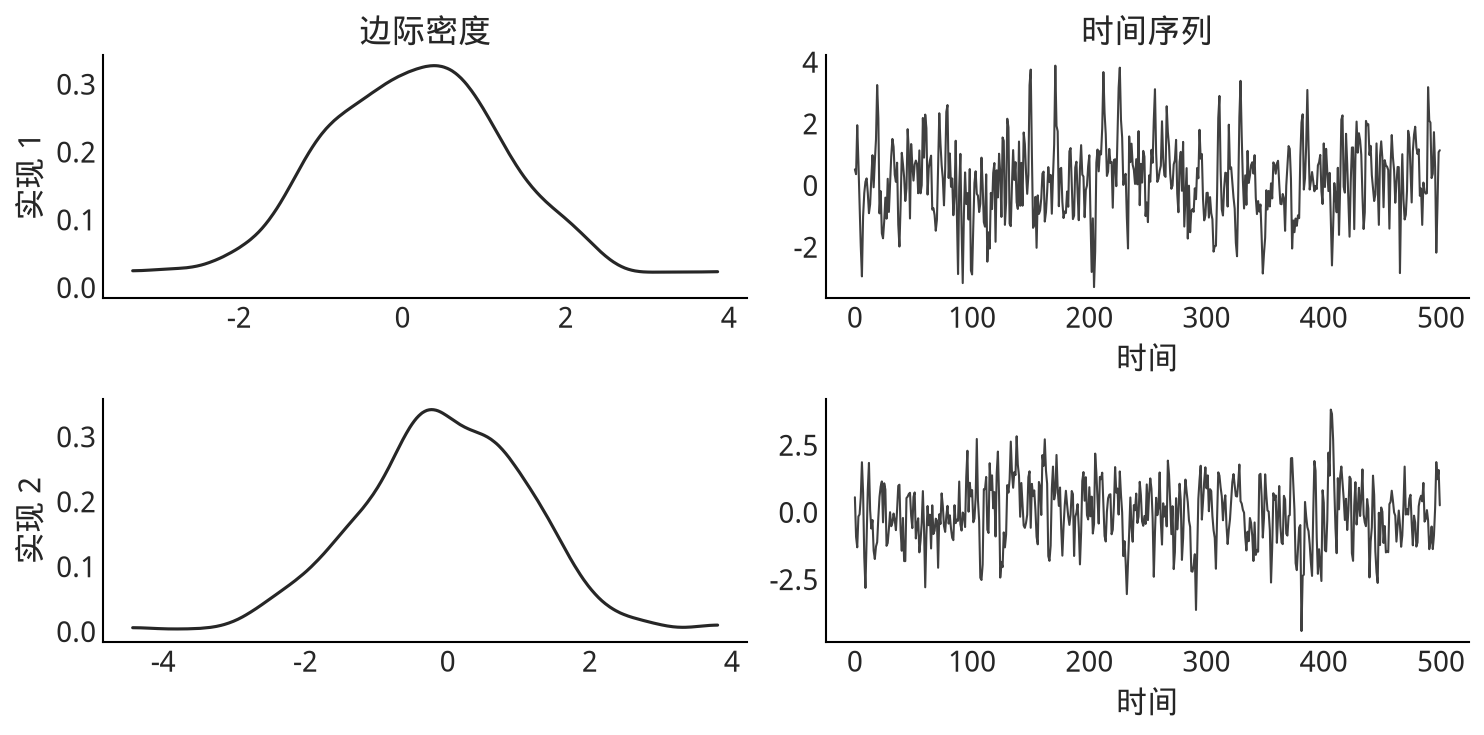

In [25]:
realization_rngs = [
    np.random.default_rng(RANDOM_SEED + 30),
    np.random.default_rng(RANDOM_SEED + 31),
]
realizations = [
    simulate_ma2(local_rng, θ1_true, θ2_true)
    for local_rng in realization_rngs
]

_, axes = plt.subplots(2, 2, figsize=(10, 5))
for row, realization in enumerate(realizations):
    az.plot_kde(realization, ax=axes[row, 0], plot_kwargs={"color": "0.15"})
    axes[row, 0].set_ylabel(f"实现 {row + 1}")
    axes[row, 1].plot(realization, color="0.25", linewidth=1)
    axes[row, 1].set_xlabel("时间")
axes[0, 0].set_title("边际密度")
axes[0, 1].set_title("时间序列")
plt.tight_layout()
plt.savefig(FIG_DIR / "ma2_simulator_abc.png")


```{figure} img/chp08/ma2_simulator_abc.png
:name: fig:ma2_simulator_abc
:width: 8.00in
$\theta_1=0.6,\theta_2=0.2$ 的 MA(2) 模型两次实现。左列为核密度估计，右列为
时间序列。
```

原则上，可用任意距离和/或摘要统计量拟合 MA($q$)，但模型性质能指导选择。常关注
的性质是自相关。理论上，MA($q$) 在大于 $q$ 的滞后处自相关为零，所以 MA(2) 可用
滞后 1 和 2 的自相关作为摘要。为避免另行计算方差，这里使用自协方差。


In [26]:
def autocov(x, n=2):
    values = np.asarray(x)
    if n < 1 or values.size <= n:
        raise ValueError("n 必须为正且小于序列长度")
    return np.array([
        np.mean(values[lag:] * values[:-lag])
        for lag in range(1, n + 1)
    ])

def _event_length(size, fallback):
    if size is None:
        return fallback
    if np.isscalar(size):
        return int(size)
    return int(np.prod(size, dtype=int))

def moving_average_2(rng, theta1, theta2, size=None):
    n_obs = _event_length(size, len(y_obs))
    innovations = rng.normal(0, 1, n_obs + 2)
    return (
        innovations[2:]
        + theta1 * innovations[1:-1]
        + theta2 * innovations[:-2]
    )


此外，若不增加限制，MA($q$) 模型不可识别。MA(1) 需要
$-1<\theta_1<1$；MA(2) 需要 $-2<\theta_1<2$、
$\theta_1+\theta_2>-1$ 且 $\theta_1-\theta_2<1$。因此必须从
{numref}`fig:ma2_triangle` 所示三角形区域采样。结合自定义摘要与可识别性限制，
ABC 模型如代码块 [MA2_abc](MA2_abc) 所示。


In [27]:
with pm.Model() as model_ma2:
    θ1 = pm.Uniform("θ1", -2, 2)
    θ2 = pm.Uniform("θ2", -1, 1)
    # 中文版现代化说明：可逆性区域（三角形）面积恰为矩形先验支撑集面积的一半，
    # 若只用 switch 把矩形先验截断到三角形而不补偿，截断后的“先验”只在其自身支撑集
    # 上积分到 0.5，不是合法密度，会让 SMC 边际似然系统性偏小 log(2)。这里把补偿项
    # np.log(2) 放在其中一个 Potential 里（只放一次，避免重复补偿）。
    p1 = pm.Potential("p1", pm.math.switch(θ1 + θ2 > -1, np.log(2), -np.inf))
    p2 = pm.Potential("p2", pm.math.switch(θ1 - θ2 < 1, 0, -np.inf))

    y = pm.Simulator(
        "y",
        moving_average_2,
        params=[θ1, θ2],
        distance="gaussian",
        sum_stat=autocov,
        epsilon=0.1,
        observed=y_obs,
    )
    idata_ma2 = pm.sample_smc(
        draws=MA_SMC_DRAWS,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 40,
        idata_kwargs={"log_likelihood": True},
    )


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

`pm.Potential` 可把任意项加入（伪）似然，而不向模型增加新变量，特别适合加入本例
这样的限制。在 [MA2_abc](MA2_abc) 中，若 `pm.math.switch` 的第一个条件为真，
就向对数似然加 0，否则加 $-\infty$。


In [28]:
az.summary(idata_ma2, var_names=["θ1", "θ2"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
θ1,0.602,0.108,0.399,0.802,0.001,0.001,11597.0,11274.0,1.0
θ2,0.307,0.135,0.045,0.549,0.001,0.001,11205.0,10410.0,1.0


/tmp/ipykernel_977548/1516999122.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


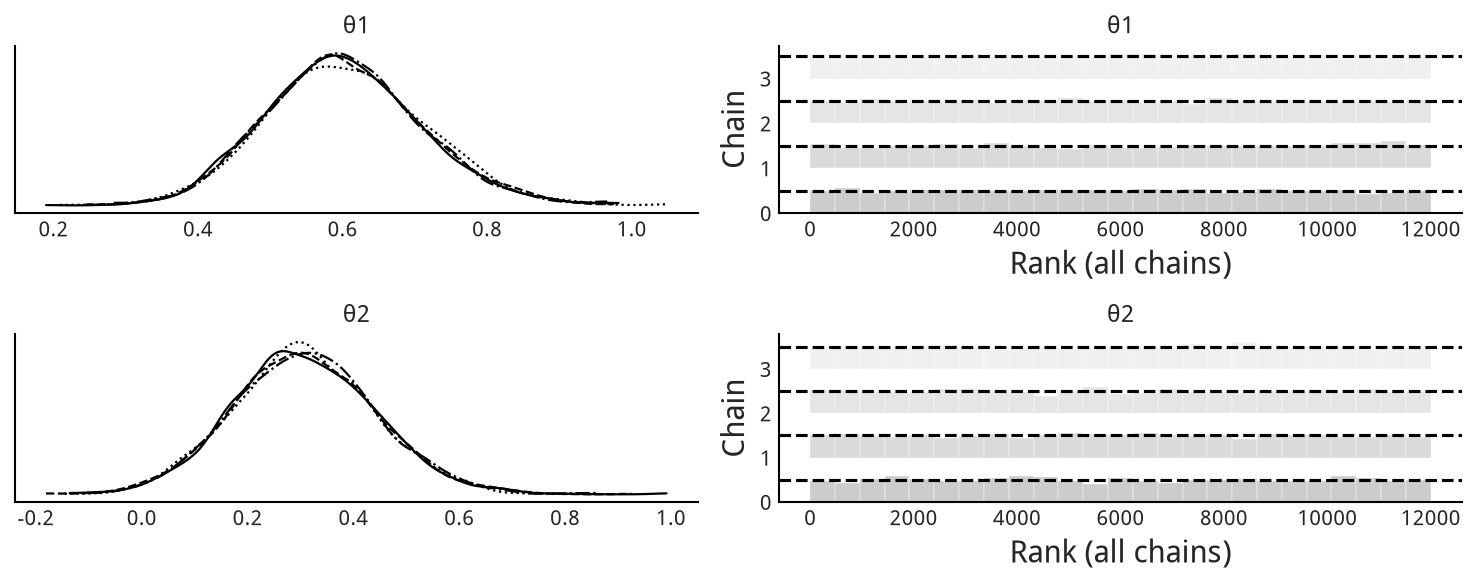

In [29]:
az.plot_trace(idata_ma2, var_names=["θ1", "θ2"], kind="rank_bars", figsize=(10, 4))
plt.tight_layout()
plt.savefig(FIG_DIR / "ma2_trace.png")


```{figure} img/chp08/ma2_trace.png
:name: fig:ma2_trace
:width: 8.00in
MA(2) 模型的 ABC 轨迹图。真实参数得到恢复，秩图也足够平坦。
```


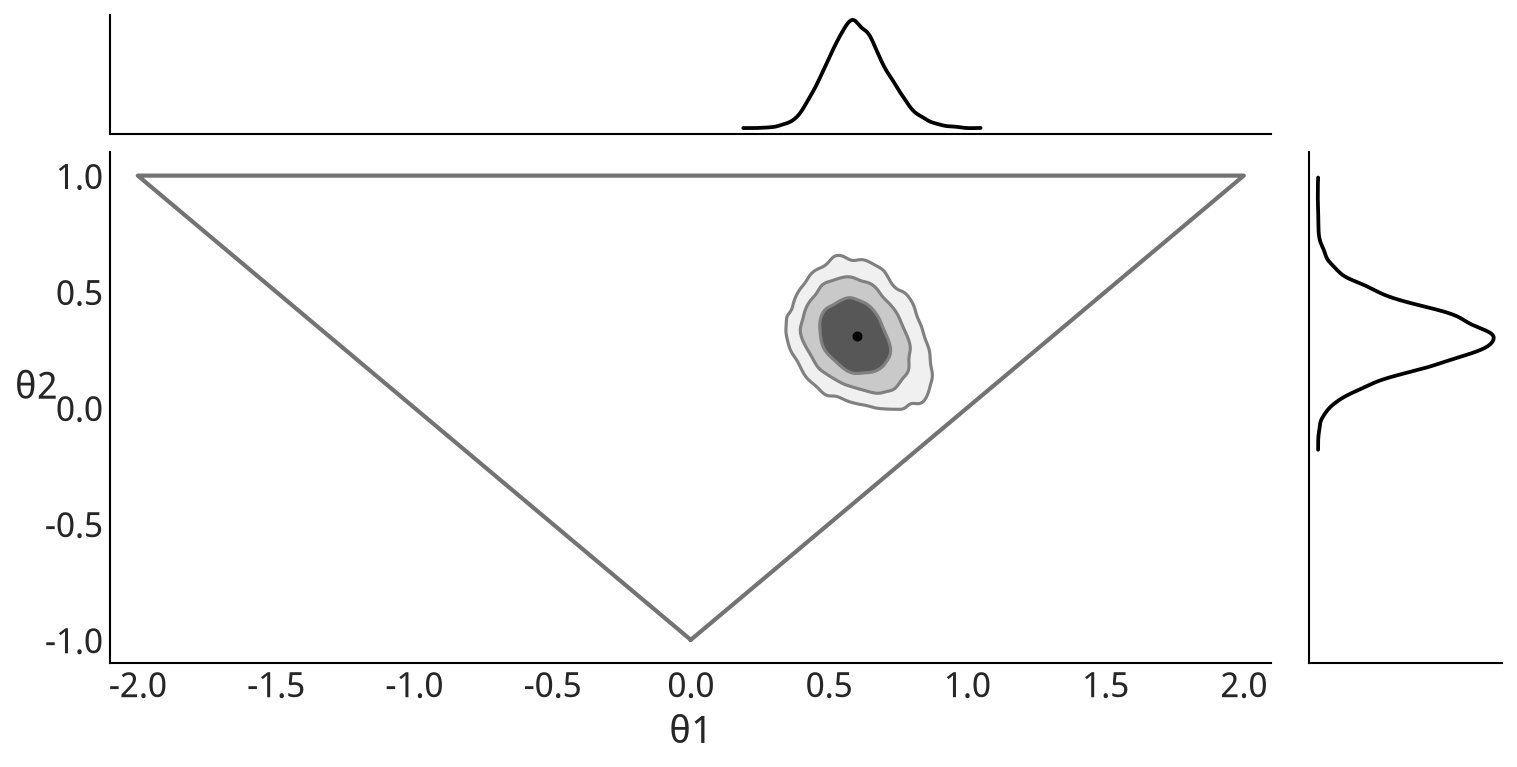

In [30]:
axes = az.plot_pair(
    idata_ma2,
    kind="kde",
    var_names=["θ1", "θ2"],
    marginals=True,
    figsize=(10, 5),
    kde_kwargs={"contourf_kwargs": {"cmap": "Greys"}},
    point_estimate="mean",
    point_estimate_kwargs={"linestyle": "none"},
    point_estimate_marker_kwargs={
        "marker": ".", "facecolor": "black", "zorder": 2,
    },
)
axes[1, 0].set_xlim(-2.1, 2.1)
axes[1, 0].set_ylim(-1.1, 1.1)
axes[1, 0].set_ylabel(axes[1, 0].get_ylabel(), rotation=0)
axes[1, 0].plot([0, 2, -2, 0], [-1, 1, 1, -1], color="0.45", linewidth=2)
plt.savefig(FIG_DIR / "ma2_triangle.png")


```{figure} img/chp08/ma2_triangle.png
:name: fig:ma2_triangle
:width: 8.00in
代码块 [MA2_abc](MA2_abc) 定义的 MA(2) ABC 后验。中央子图是联合后验，边缘
是 $\theta_1$ 与 $\theta_2$ 的边际分布。灰色三角形表示先验允许区域，黑点表示
均值。
```


(model-comparison-in-the-abc-context)=

## ABC 语境中的模型比较

ABC 经常用于模型选择。已有许多方法 {cite:p}`Sisson2018, Beaumont2019`，本章
讨论两类：包括与 LOO 对照的贝叶斯因子，以及随机森林 {cite:p}`Pudlo2015`。

和参数推断一样，摘要选择对模型比较至关重要。若两个或更多模型给出大致相同预测，
就无法仅凭这些预测偏爱其中一个。ABC 摘要统计量下也一样：如果只以均值为摘要，而
各模型预测同一均值，该摘要便无法区分模型。应仔细思考模型真正不同之处。

(marginal-likelihood-and-loo)=

### 边际似然与 LOO

ABC 模型比较常使用边际似然。两个边际似然的比称为贝叶斯因子；比值大于 1 时偏好
分子模型，反之偏好分母模型。详见 {ref}`Bayes_factors`，其中也讨论了局限。边际
似然通常很难计算；所幸 SMC 及 SMC-ABC 可在采样过程中顺带计算它。当前 PyMC 把
每个阶段的对数边际似然保存在 `InferenceData.sample_stats` 中。由于值在对数尺度，
贝叶斯因子应计算为：

```python
bayes_factor_1_over_2 = np.exp(log_ml_1 - log_ml_2)
```

若 ABC 使用摘要统计量，边际似然通常不能可靠地区分竞争模型 {cite:p}`Robert2011`，
除非摘要对模型比较充分。令人担忧的是，除少数形式化例子和特定模型外，没有通用
方法确保跨模型充分性 {cite:p}`Robert2011`。若使用全部数据，则没有这个摘要丢失
信息的问题[^10]。这呼应 {ref}`Bayes_factors` 的讨论：计算边际似然通常比计算后验
更难；一个足以算出良好后验的摘要，并不保证适合模型比较。

为理解 ABC 中边际似然的行为，原书做了一个小实验，并加入我们总体更偏好的 LOO。
实验比较三类模型的对数边际似然和 LOO：显式似然模型、使用完整数据的模拟器 ABC、
以及使用摘要统计量的 ABC。结果见 {numref}`fig:model_comp_normal_0`。边际（伪）
似然由 SMC 顺带计算，LOO 由 `az.loo()` 计算。严格说，LOO 定义在逐点对数似然上；
ABC 中得到的是逐点对数*伪*似然。


从 {numref}`fig:model_comp_normal_0` 看，LOO 和对数边际似然总体行为相似。第一列
中，`model_1` 始终优于 `model_0`（越高越好）。对数边际似然的模型差异（连线
斜率）比 LOO 大，因为边际似然显式纳入先验，而 LOO 只通过后验间接纳入先验
（详见 {ref}`Bayes_factors`）。尽管数值随重复样本变化，变化方向一致；连接模型的
线斜率非常相近，这是理想的模型选择行为。

比较 `model_1` 与 `model_2` 时结论类似：LOO 几乎无法区分二者，而边际似然显示
更大差异，原因仍是前者只基于后验，后者直接考虑先验。

```{figure} img/chp08/model_comp_normal_00.png
:name: fig:model_comp_normal_0
:width: 8.00in
`model_0` 类似公式 {eq}`eq:Gauss_model`，但
$\sigma\sim\mathcal{HN}(0.1)$；`model_1` 就是该公式；`model_2` 则令
$\sigma\sim\mathcal{HN}(10)$。第一行是对数边际似然，第二行是 LOO。各列依次为
SMC、使用完整数据的 `SMC-ABC`、只用均值摘要的 `SMC-ABC_sm`、以及使用均值和
标准差的 `SMC-ABC_sq`。每种配置重复 50 次，每次样本量 50。
```

第二列进入 ABC 情形。`model_1` 仍然更好，但 `model_0` 的离散程度远大于另两个
模型，而且连线开始交叉。由此看来，LOO 或对数边际似然或许仍能选出最佳模型，
但 `az.compare()` 相对权重或贝叶斯因子的变异会更大。

第三列只用均值作摘要。此时 `model_0` 与 `model_1` 似乎不相上下，`model_2` 很差，
几乎是上一列的镜像。这说明带摘要的 ABC 中，对数边际似然与 LOO 可能给出不合理
答案。第四列再加入标准差后，定性上恢复了使用完整数据时的行为。

::: {admonition} 伪似然的尺度（On the scale of the pseudolikelihood）
注意各图的纵轴尺度不同，尤其是不同列之间。原因有二：第一，ABC 用经 $\epsilon$
缩放的核函数近似似然；第二，摘要统计量减小了数据大小。对均值或分位数这类摘要，
即使原始样本量从 10 增至 1000，摘要大小仍不变——均值始终只是一个数。
:::


{numref}`fig:model_comp_normal_forest` 有助于理解上一幅图，建议把两图放在一起分析。
这里强调两点。第一，`SMC-ABC_sm` 的均值摘要关于均值充分，却完全不描述数据离散
程度，因此参数 `a` 和 `σ` 的后验不确定性主要由先验控制：`model_0` 和 `model_1`
对 `μ` 的估计很像，而 `model_2` 的不确定性大得不合理。

第二，对 `σ` 而言，`model_0` 的不确定性很小，`model_1` 比应有的更宽，
`model_2` 同样大得不合理。这解释了为何对数边际似然与 LOO 认为前两个模型相近、
第三个不同：`SMC-ABC_sm` 根本没有提供良好拟合。因此它的结果与 `SMC` 或使用
全数据的 `SMC-ABC` 矛盾并不奇怪。把均值和标准差共同作为摘要的 `SMC-ABC_sq`
能部分恢复全数据 ABC 的行为。

```{figure} img/chp08/model_comp_normal_forest.png
:name: fig:model_comp_normal_forest
:width: 8.00in
三个模型与 {numref}`fig:model_comp_normal_0` 相同。图中按 SMC、完整数据 ABC、
仅均值摘要、均值加标准差摘要展示 50 次重复实验的参数后验，从而说明摘要如何影响
拟合和模型比较。
```

{numref}`fig:model_comp_pois_geom_0` 与
{numref}`fig:model_comp_pois_geom_forest` 给出类似分析，但 `model_0` 是几何模型，
`model_1` 是 Poisson 模型；数据服从平移 Poisson 分布
$1+\operatorname{Pois}(2.5)$。具体分析留作练习。

```{figure} img/chp08/model_comp_pois_geom_00.png
:name: fig:model_comp_pois_geom_0
:width: 8.00in
`model_0` 是先验 $p\sim\mathcal U(0,1)$ 的几何分布，`model_1` 是先验
$\mu\sim\mathcal E(1)$ 的 Poisson 分布；数据来自
$1+\operatorname{Pois}(2.5)$。各列依次为 SMC、完整数据 ABC、均值摘要 ABC、
均值与标准差摘要 ABC。每种配置重复 50 次，每次样本量 50。
```

```{figure} img/chp08/model_comp_pois_geom_forest.png
:name: fig:model_comp_pois_geom_forest
:width: 8.00in
同一几何模型与 Poisson 模型的后验森林图。各列比较 SMC、完整数据 ABC、均值摘要
ABC 与分位数摘要 ABC；每种配置重复 50 次，每次样本量 50。原图文字中的摘要缩写
有重复，中文版按实验含义明确表述。
```


ABC 文献常用贝叶斯因子给模型分配相对概率。某些领域会认为这很有价值，但我们要
提醒实践者注意 ABC 下的潜在问题，尤其因为使用摘要比使用全数据常见得多。模型比较
仍然有用，特别是采取探索性立场，并在比较之前进行模型批判，改进或排除明显错误的
模型。本书对非 ABC 方法一直采用这种流程，也自然应扩展到 ABC。

本书还偏好 LOO 而非边际似然。关于 LOO 在 ABC 下利弊的研究仍不足，但它有潜在
用处，未来还需更多证据。

::: {admonition} 模型批判与模型比较（Model criticism and model comparison）
模型总会有一定程度的错误设定，模型比较也能帮助理解这些错误；但只有先证明模型能
合理拟合数据，才应比较。比较一组明显拟合很差的模型没有太大意义。
:::


(model-choice-via-random-forest)=

### 用随机森林选择模型

上一节的局限推动了 ABC 模型选择新方法的研究。其中一种把模型选择重构为随机森林
分类问题 {cite:p}`Pudlo2015`[^11]。随机森林把许多决策树组合起来用于分类或回归，
与[第 7 章](chap6)的 BART 密切相关。

核心思想是：从先验预测或后验预测模拟数据，构造随机森林分类器，即可找出概率最高
的模型。原论文使用先验预测，并指出更高级的 ABC 方法也可使用其他分布；本章采用
后验预测。对至多 $m$ 个模型，把模拟结果排列为参考表
（{numref}`table:ABC_random_forest_ref_table`）：每行是一次后验预测样本，每列是
$n$ 个摘要统计量之一。以此训练分类器，根据摘要值识别模型。

模型选择所用摘要不必与拟合后验时相同；事实上，通常建议纳入很多摘要。训练完成
后，对观测数据计算同样的 $n$ 个摘要并送入分类器，预测类别就是最佳模型。

```{list-table} 参考表
:name: table:ABC_random_forest_ref_table
:header-rows: 1

* - **模型**
  - $\mathbf{S^0}$
  - $\mathbf{S^1}$
  - $\cdots$
  - $\mathbf{S^n}$
* - 0
  - $S^0(y_0^{(1)})$
  - $S^1(y_0^{(1)})$
  - $\cdots$
  - $S^n(y_0^{(1)})$
* - 0
  - $S^0(y_0^{(2)})$
  - $S^1(y_0^{(2)})$
  - $\cdots$
  - $S^n(y_0^{(2)})$
* - $\vdots$
  - $\vdots$
  - $\vdots$
  - $\ddots$
  - $\vdots$
* - 1
  - $S^0(y_1^{(1)})$
  - $S^1(y_1^{(1)})$
  - $\cdots$
  - $S^n(y_1^{(1)})$
* - $m$
  - $S^0(y_m^{(1)})$
  - $S^1(y_m^{(1)})$
  - $\cdots$
  - $S^n(y_m^{(1)})$
```

还可以估计“最佳”模型相对于其余模型的局部正确分类程度。方法仍是随机森林，但这次
做回归：以误分类误差率为响应，以参考表摘要为自变量 {cite:p}`Pudlo2015`。


(model-choice-for-ma-model)=

### 为 MA 模型选择阶数

回到移动平均例子：MA(1) 还是 MA(2) 更好？我们使用基于逐点伪似然的 LOO 和随机
森林回答。先以修正后的模拟器重新生成一份 $\theta_1=0.7,\theta_2=0.3$ 的 MA(2)
观测数据，并定义 MA(1) 模拟器。

(MA1_abc)=


In [31]:
def moving_average_1(rng, theta1, size=None):
    n_obs = _event_length(size, len(y_obs))
    innovations = rng.normal(0, 1, n_obs + 1)
    return innovations[1:] + theta1 * innovations[:-1]

def moving_average_2(rng, theta1, theta2, size=None):
    n_obs = _event_length(size, len(y_obs))
    innovations = rng.normal(0, 1, n_obs + 2)
    return (
        innovations[2:]
        + theta1 * innovations[1:-1]
        + theta2 * innovations[:-2]
    )

choice_rng = np.random.default_rng(RANDOM_SEED + 50)
θ1_true = 0.7
θ2_true = 0.3
y_obs = simulate_ma2(choice_rng, θ1_true, θ2_true)


In [32]:
# 随机森林模型选择将使用前六个自协方差；拟合仍默认使用前两个。
autocov_6 = partial(autocov, n=6)


In [33]:
with pm.Model() as model_ma1:
    θ1 = pm.Uniform("θ1", -1, 1)
    y = pm.Simulator(
        "y",
        moving_average_1,
        params=[θ1],
        distance="gaussian",
        sum_stat=autocov,
        epsilon=0.1,
        observed=y_obs,
    )
    idata_ma1 = pm.sample_smc(
        draws=MA_SMC_DRAWS,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 51,
        idata_kwargs={"log_likelihood": True},
    )


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

In [34]:
with pm.Model() as model_ma2_choice:
    θ1 = pm.Uniform("θ1", -2, 2)
    θ2 = pm.Uniform("θ2", -1, 1)
    # 中文版现代化说明：可逆性区域（三角形）面积恰为矩形先验支撑集面积的一半，
    # 若只用 switch 把矩形先验截断到三角形而不补偿，截断后的“先验”只在其自身支撑集
    # 上积分到 0.5，不是合法密度，会让 SMC 边际似然系统性偏小 log(2)。这里把补偿项
    # np.log(2) 放在其中一个 Potential 里（只放一次，避免重复补偿）。
    p1 = pm.Potential("p1", pm.math.switch(θ1 + θ2 > -1, np.log(2), -np.inf))
    p2 = pm.Potential("p2", pm.math.switch(θ1 - θ2 < 1, 0, -np.inf))
    y = pm.Simulator(
        "y",
        moving_average_2,
        params=[θ1, θ2],
        distance="gaussian",
        sum_stat=autocov,
        epsilon=0.1,
        observed=y_obs,
    )
    idata_ma2_choice = pm.sample_smc(
        draws=MA_SMC_DRAWS,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 52,
        idata_kwargs={"log_likelihood": True},
    )

# 中文版现代化说明：本章局部 select_model 用 pm.sample_prior_predictive
# 构造参考表，而先验预测不会应用 Potential，因此不能像上面 model_ma2_choice
# 那样用 Potential 实现可逆性约束（select_model 会显式拒绝带 Potential 的模型）。
# 这里改用等价的规范化生成式先验：先取 θ2~Uniform(-1,1)，再取
# θ1~Uniform(-1-θ2, 1+θ2)——这正是可逆性三角形在给定 θ2 处的截面，
# 因此不需要拒绝采样或 Potential 就能得到三角形上的均匀联合先验，
# 与 model_ma2_choice 表示同一个先验，仅参数化方式不同。
with pm.Model() as model_ma2_rf:
    θ2 = pm.Uniform("θ2", -1, 1)
    θ1 = pm.Uniform("θ1", -1 - θ2, 1 + θ2)
    y = pm.Simulator(
        "y",
        moving_average_2,
        params=[θ1, θ2],
        distance="gaussian",
        sum_stat=autocov,
        epsilon=0.1,
        observed=y_obs,
    )


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

In [35]:
def final_log_marginal_likelihood(idata):
    statistic = idata.sample_stats["log_marginal_likelihood"]
    if "chain" in statistic.dims:
        chain_slices = [
            statistic.isel(chain=index).values
            for index in range(statistic.sizes["chain"])
        ]
    else:
        chain_slices = [statistic.values]

    chain_finals = []
    for chain_slice in chain_slices:
        scalars = []
        for item in np.asarray(chain_slice, dtype=object).reshape(-1):
            try:
                scalars.extend(np.asarray(item, dtype=float).reshape(-1))
            except (TypeError, ValueError):
                continue
        finite = np.asarray(scalars, dtype=float)
        finite = finite[np.isfinite(finite)]
        if finite.size:
            chain_finals.append(finite[-1])
    if not chain_finals:
        raise ValueError("没有有限的最终对数边际似然")
    # 中文版现代化说明：多条链各自是同一边际似然的独立估计，须在线性尺度取平均
    # 后再取对数（log-mean-exp），而不是直接对对数值取算术平均——由 log 的凹性，
    # 后者是几何平均，只要链间估计存在方差就会系统性偏低。
    chain_finals = np.asarray(chain_finals, dtype=float)
    log_count = np.log(chain_finals.size)
    peak = np.max(chain_finals)
    return float(peak + np.log(np.sum(np.exp(chain_finals - peak))) - log_count)

log_ml_ma1 = final_log_marginal_likelihood(idata_ma1)
log_ml_ma2 = final_log_marginal_likelihood(idata_ma2_choice)
bayes_factor_ma2_over_ma1 = np.exp(log_ml_ma2 - log_ml_ma1)
bayes_factor_ma2_over_ma1


np.float64(1.7794738379561985)

原版在用 LOO 比较 ABC 模型前，需要手工把 `trace.report.log_pseudolikelihood` 转成
`InferenceData.log_likelihood`，见代码块 [idata_pseudo](idata_pseudo)[^12]。
当前 PyMC 可在 `sample_smc(..., idata_kwargs={"log_likelihood": True})` 时直接生成
该组，因此不再使用已移除的 `az.from_pymc3` 或私有的 `dict_to_dataset`。

(idata_pseudo)=
```python
comparison = az.compare({"model_ma1": idata_ma1,
                         "model_ma2": idata_ma2_choice})
```

原书比较结果汇总如下；它说明 MA(2) 在该次历史运行中更受偏好。当前软件版本、随机
样本与伪逐点似然可使具体数值和排序变化，因此必须同时检查 Pareto-$k$ 警告与模型
拟合，而不能把表中的数字当作固定基准。

> **中文版现代化说明**：这里的“逐点”是相对代码块 [MA1_abc](MA1_abc)、
> [MA2_abc](MA2_abc) 里 `sum_stat=autocov` 返回的 2 个滞后自协方差摘要而言，
> 并非原始约 100 个观测点。也就是说，`az.loo()` 在这里实际上是对 2 个摘要统计量
> 做留一交叉验证，而不是常规意义上逐个原始观测的 LOO；样本量极小也是 Pareto-$k$
> 警告和排序不稳定的部分原因，解读时应留意这一点。

```{list-table} 使用 LOO 的 ABC 模型比较摘要（原书运行）
:name: table:abc_loo
:header-rows: 1

* - **模型**
  - **rank**
  - **loo**
  - **p_loo**
  - **d_loo**
  - **weight**
  - **se**
  - **dse**
  - **warning**
  - **loo_scale**
* - model_ma2
  - 0
  - -2.22
  - 1.52
  - 0.00
  - 1.0
  - 0.08
  - 0.00
  - False
  - log
* - model_ma1
  - 1
  - -3.53
  - 2.04
  - 1.31
  - 0.0
  - 1.50
  - 1.43
  - False
  - log
```


In [36]:
comparison = az.compare(
    {"model_ma1": idata_ma1, "model_ma2": idata_ma2_choice}
)
comparison


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:1042: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely 

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_ma1,0,-18.102053,14.663191,0.000000,1.0,3.850218,0.000000,True,log
model_ma2,1,-41.297979,39.948309,23.195927,0.0,10.345277,14.195494,True,log


随机森林方法使用本章局部的 `select_model`。传入 `(PyMC 模型, InferenceData)` 对、
摘要统计函数和观测数据。本例用前六个自协方差，原因有二：一是展示模型选择摘要
可以不同于拟合摘要；二是展示可把有用的前两个自协方差与不太有用的其余四个混合。
理论上 MA($q$) 最多只有前 $q$ 个非零自相关。群体遗传学等复杂问题使用几百、几千
乃至数万个摘要并不少见 {cite:p}`Collin2020`。

> **中文版现代化说明**：`select_model` 用先验预测构造参考表，而先验预测不会
> 应用 `pm.Potential`；因此这里对 MA(2) 用 `model_ma2_rf`（用
> θ1~Uniform(-1-θ2, 1+θ2) 的规范化生成式先验表示同一个可逆性三角形），
> 而不是用于 SMC 拟合的 `model_ma2_choice`。两者先验相同，只是参数化方式
> 不同；MA(1) 的 `model_ma1` 本身没有用 Potential，可以直接复用。


In [37]:
best_model_index, local_misclassification_probability = select_model(
    [(model_ma1, idata_ma1), (model_ma2_rf, idata_ma2_choice)],
    statistics=[autocov_6],
    n_samples=RF_REFERENCE_SAMPLES,
    n_trees=RF_TREES,
    observations=y_obs,
    random_seed=RANDOM_SEED + 60,
)
best_model_index, local_misclassification_probability


Sampling: [y, θ1]


Sampling: [y, θ1, θ2]


(1, 0.0)

`select_model` 返回从 0 开始的最佳模型索引，以及回归森林估计的**局部误分类概率**。
原书一次运行得到索引 0，并把第二个值 0.68 描述为该模型概率；中文版保留这一历史
结果作为出处，同时纠正解释：第二个值越小，分类器在观测摘要邻域越有把握，它不是
经校准的后验模型概率。具体选择也会随模拟参考表变化。至少在原书示例中，LOO 与
随机森林对模型选择及相对权重给出了大致一致的信息。


(choosing-priors-for-abc)=

## 为 ABC 选择先验

没有闭式似然会使良好建模更困难，所以 ABC 往往比其他近似方法更脆弱。我们应比有
显式似然时更谨慎地作出模型选择（包括先验引出），也要更彻底地评估模型；这是近似
似然付出的代价。

在 ABC 中，认真引出先验可能比在其他方法中收获更大。若近似似然损失了信息，更有
信息的先验也许能部分补偿；更好的先验通常还能避免浪费计算资源和时间。ABC 拒绝法
直接以先验作提议分布，这一点很直观；SMC 同样如此，特别是模拟器对输入参数敏感时。

例如，用 ABC 推断常微分方程时，某些参数组合可能在数值上很难模拟，导致一次模拟
极慢。模糊先验还会在 SMC/SMC-ABC 加权阶段造成问题：先验样本在退火后验上的权重
几乎全都极小，只有少数很大，粒子在几步后就退化为少数重复值。这称为权重坍缩，是
粒子方法的已知问题 {cite:p}`bickel2008sharp`。

良好先验能降低计算成本，并在一定程度上允许 SMC/SMC-ABC 拟合更复杂的模型。除
“采用更有信息的先验”这一总原则，以及本书其他章节关于先验引出和评估的讨论外，
我们没有更多只针对 ABC 的建议。


(exercises8)=

## 练习

**8E1.** 用自己的话解释 ABC 在何种意义上是近似的：近似了什么对象或量，又是如何
近似的？

**8E2.** 在 ABC 语境中，与拒绝采样相比，SMC 试图解决什么问题？

**8E3.** 编写 Python 函数，计算公式 {eq}`eq:euclidean_abc` 中不含求和的高斯核。
从同一分布生成两个大小为 100 的随机样本，用函数逐项计算两者距离；你会得到两个
各含 100 个值的分布。用 KDE 图、均值和标准差展示差异。

**8E4.** 若 [gauss_abc](gauss_abc) 的 `gauss` 模型使用
`sum_stat="identity"`，你预计结果的准确性和采样器收敛性会怎样？说明理由。

**8E5.** 使用 `sum_stat="identity"` 重新拟合 [gauss_abc](gauss_abc)，并用以下
工具评估：

1. 轨迹图；
2. 秩图；
3. $\hat R$；
4. 参数 $\mu$ 与 $\sigma$ 的均值和 HDI。

与书中使用 `sum_stat="sort"` 的结果比较。

**8E6.** 使用五分位数作摘要统计量，重新拟合 [gauss_abc](gauss_abc)。

1. 结果与书中例子相比如何？
2. 尝试其他 `epsilon`；1 是好选择吗？

**8E7.** 使用 `GAndKQuantile` 生成大小为 500、参数
$a=0,b=1,g=0.4,k=0$ 的 g-and-k 样本，再用 `gkm` 分别取
$\epsilon=0.05,0.1,0.5$ 拟合。哪个 $\epsilon$ 最合适？使用诊断工具支持答案。

**8E8.** 使用上一题样本和 `gkm`，分别以 `octo_summary`、八分位向量
（0.125、0.25、0.375、0.5、0.625、0.75、0.875）及排序后的完整数据为摘要。
将结果与已知参数比较：哪个方案准确性更高、不确定性更低？


**8M9.** GitHub 仓库中有科学论文引用次数分布数据。用 SMC-ABC 为它拟合 g-and-k
分布，完成寻找合适 `epsilon`、确认模型收敛并验证拟合适当所需的全部步骤。

**8M10.** Lotka–Volterra 是描述捕食者—猎物相互作用下两个物种数量变化的著名
生物模型 {cite:p}`Otto2007`。猎物增加会给捕食者提供更多食物，促使捕食者增加；
大量捕食者又会使猎物减少，食物匮乏继而使捕食者减少。在一定条件下，两类种群会
形成稳定周期。仓库中提供了未知参数的 Lotka–Volterra 模拟器和数据集
`Lotka-Volterra_00`（本章 `data/Lotka-Volterra_00.csv`）。假设未知参数均为正，
用 SMC-ABC 求参数后验。

**8H11.** 继续 Lotka–Volterra 例子。`Lotka-Volterra_01` 描述的捕食者—猎物系统
在某一时刻因疾病突然大量损失猎物。扩展模型以允许一个“切换点”，即把时间分成两种
捕食—猎物动力学（也就是两组不同参数）的时点。

> **中文版补充**：本发行版仅包含 `Lotka-Volterra_00` 数据集；`Lotka-Volterra_01`
> 未随附，需要自行按题目描述模拟一段带切换点的捕食者—猎物序列（例如用
> 8M10 的模拟器分两段、以不同参数各生成一部分，再拼接）才能完成本题。

**8H12.** 本题基于 Rasmus Bååth 提出的袜子问题。我们从洗衣物中拿出 11 只袜子，
惊讶地发现每只都不同，无法配成一双。洗衣物中一共有多少只袜子？假设其中既有成双
也有落单的袜子，同一种不超过两只，即每种袜子恰有 1 或 2 只。

假设袜子总数服从 $\operatorname{NB}(30,4.5)$，落单袜子比例服从
$\operatorname{Beta}(15,2)$。构造适合本问题的模拟器，并建立 SMC-ABC 模型，计算
袜子总数、落单比例和配成对的袜子有多少双的后验分布。


[^1]: 对离散变量可以实现完全匹配，尤其当变量只有少数可能取值时。

[^2]: 这是维数灾难的另一种表现，完整解释见 {ref}`high_dimensions`。

[^3]: 原版 PyMC3 SMC 的默认 `kernel` 是 `"metropolis"`，详见
    {ref}`inference_methods`；当前 PyMC API 已不再用该参数选择 ABC。

[^4]: 高斯核类似高斯分布，但没有归一化项
    $\frac{1}{\sigma\sqrt{2\pi}}$。

[^5]: 这是 PyMC 的实现选择，其他软件包可能不同。

[^6]: 虽然 PyMC 把 `sum_stat="sort"` 称为摘要统计量，但排序并不是真正的摘要，
    因为仍然使用了全部数据。

[^7]: 这类似前述 SMC/SMC-ABC 算法描述中的 $\beta$ 参数序列。

[^8]: Prangle {cite:p}`prangle2017` 描述了一个包含大量 g-and-k 分布工具的 R 包。

[^9]: 文献通常用 $\varepsilon$ 表示白噪声项；这里为避免与 SMC-ABC 的
    $\epsilon$ 参数混淆而改用 $\lambda$。

[^10]: 应再次记住，`sum_stat="sort"` 并非真正摘要，因为它使用完整数据集。

[^11]: 也可选择其他分类器，但原论文作者采用了随机森林。

[^12]: 原书预期未来 PyMC 的 `pm.sample_smc` 会返回含正确分组的 `InferenceData`；
    当前版本已经实现，因此中文版不再手工转换 PyMC3 trace。
